In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv('/content/cleaned_aqi_data.csv')

In [4]:
df.head()

,T,TM,Tm,SLP,H,VV,V,VM,PM 2.5
0,28.5,34.7,22.0,1006.9,64.0,0.0,1.9,6.1,284.795833
1,9.1,15.3,4.0,1015.6,90.0,0.0,0.5,0.0,239.695455
2,7.4,9.8,4.8,1017.6,93.0,0.0,0.5,4.3,182.187500
3,7.8,12.7,4.4,1018.5,87.0,0.0,0.6,4.4,197.635714
4,6.9,15.7,2.9,1016.4,85.0,0.0,0.6,2.8,297.100000


In [5]:
df.tail()

,T,TM,Tm,SLP,H,VV,V,VM,PM 2.5
2083,18.9,28.1,8.6,1016.7,58.0,0.0,1.9,3.5,223.250000
2084,17.7,27.4,8.6,1017.8,67.0,0.0,1.6,1.9,248.958333
2085,18.3,26.0,8.4,1015.2,68.0,0.0,1.6,0.6,441.416667
2086,17.4,25.0,9.8,1015.0,72.0,0.0,1.8,2.0,237.791667
2087,17.5,25.1,8.8,1015.7,67.0,0.0,1.9,4.8,334.875000


### EDA (YData Profiling (Pandas Profiling))

In [64]:
# 1. Install YData Profiling
!pip install -q ydata-profiling

import pandas as pd
from ydata_profiling import ProfileReport

# 2. Generate Interactive EDA Profile Report
# Hamara original / cleaned dataset profiling ke liye pass kar rahe hain
profile = ProfileReport(
    df,
    title="PM 2.5 Air Quality Dataset - Complete Profiling Report",
    explorative=True
)

# 3. Colab Notebook ke andar display karein
profile.to_notebook_iframe()

# 4. Save report as standalone HTML File
profile.to_file("pm25_aqi_data_profiling_report.html")

# 5. Download HTML file locally (for presentation / client submit)
from google.colab import files
files.download("pm25_aqi_data_profiling_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 106.31it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
df.isnull().sum()

,0
T,0
TM,0
Tm,0
SLP,0
H,0
VV,0
V,0
VM,0
PM 2.5,0


In [9]:
df.describe()

,T,TM,Tm,SLP,H,VV,V,VM,PM 2.5
count,2088.000000,2088.000000,2088.000000,2088.000000,2088.000000,2088.000000,2088.000000,2088.000000,2088.000000
mean,26.403209,33.132471,20.089703,1007.268103,62.786686,2.930714,2.053017,6.502155,119.420846
std,6.771880,6.258057,7.148607,7.167915,15.585963,17.775760,0.718528,3.852541,86.598995
min,6.600000,9.800000,1.900000,989.800000,20.000000,0.000000,0.300000,0.000000,2.095238
25%,21.300000,29.100000,14.000000,1001.000000,54.000000,0.000000,1.600000,3.700000,51.753623
50%,28.500000,34.700000,22.000000,1006.900000,64.000000,0.000000,1.900000,6.100000,92.250000
75%,31.500000,37.000000,26.000000,1013.800000,74.000000,0.000000,2.600000,8.900000,166.708333
max,39.900000,45.700000,34.000000,1023.100000,99.000000,341.120000,8.900000,24.400000,536.500000


## Step 1: Missing Values Check

In [10]:
# Column-wise missing values ka count aur percentage check karein
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percent
})
display(missing_df)

,Missing Count,Percentage (%)
T,0,0.0
TM,0,0.0
Tm,0,0.0
SLP,0,0.0
H,0,0.0
VV,0,0.0
V,0,0.0
VM,0,0.0
PM 2.5,0,0.0


## Step 2: Hidden Missing / Invalid String Values Check

In [11]:
# Common non-numeric placeholders identify karein
invalid_symbols = ["-", "---", "NoData", "PwrFail", "InVld", "NA", "null", ""]

for col in df.columns:
    invalid_count = df[col].astype(str).str.strip().isin(invalid_symbols).sum()
    print(f"Column '{col}': {invalid_count} invalid string entries")

Column 'T': 0 invalid string entries
Column 'TM': 0 invalid string entries
Column 'Tm': 0 invalid string entries
Column 'SLP': 0 invalid string entries
Column 'H': 0 invalid string entries
Column 'VV': 0 invalid string entries
Column 'V': 0 invalid string entries
Column 'VM': 0 invalid string entries
Column 'PM 2.5': 0 invalid string entries


## Step 3: Data Types & Unique Values Check

In [12]:
# Data types aur non-null values overview
print("--- Data Info ---")
df.info()

print("\n--- Unique Values Count ---")
print(df.nunique())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2088 entries, 0 to 2087
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   T       2088 non-null   float64
 1   TM      2088 non-null   float64
 2   Tm      2088 non-null   float64
 3   SLP     2088 non-null   float64
 4   H       2088 non-null   float64
 5   VV      2088 non-null   float64
 6   V       2088 non-null   float64
 7   VM      2088 non-null   float64
 8   PM 2.5  2088 non-null   float64
dtypes: float64(9)
memory usage: 146.9 KB

--- Unique Values Count ---
T         285
TM        280
Tm        277
SLP       287
H         135
VV         90
V          35
VM        122
PM 2.5    977
dtype: int64


## Step 4: Summary Statistics & Outlier Check

In [13]:
# Mean, Min, Max, Quantiles analysis
display(df.describe().T[['min', '25%', '50%', '75%', 'max', 'std']])

,min,25%,50%,75%,max,std
T,6.600000,21.300000,28.50,31.500000,39.90,6.771880
TM,9.800000,29.100000,34.70,37.000000,45.70,6.258057
Tm,1.900000,14.000000,22.00,26.000000,34.00,7.148607
SLP,989.800000,1001.000000,1006.90,1013.800000,1023.10,7.167915
H,20.000000,54.000000,64.00,74.000000,99.00,15.585963
VV,0.000000,0.000000,0.00,0.000000,341.12,17.775760
V,0.300000,1.600000,1.90,2.600000,8.90,0.718528
VM,0.000000,3.700000,6.10,8.900000,24.40,3.852541
PM 2.5,2.095238,51.753623,92.25,166.708333,536.50,86.598995


## Step 5: Visual Outlier Detection (Box Plots)

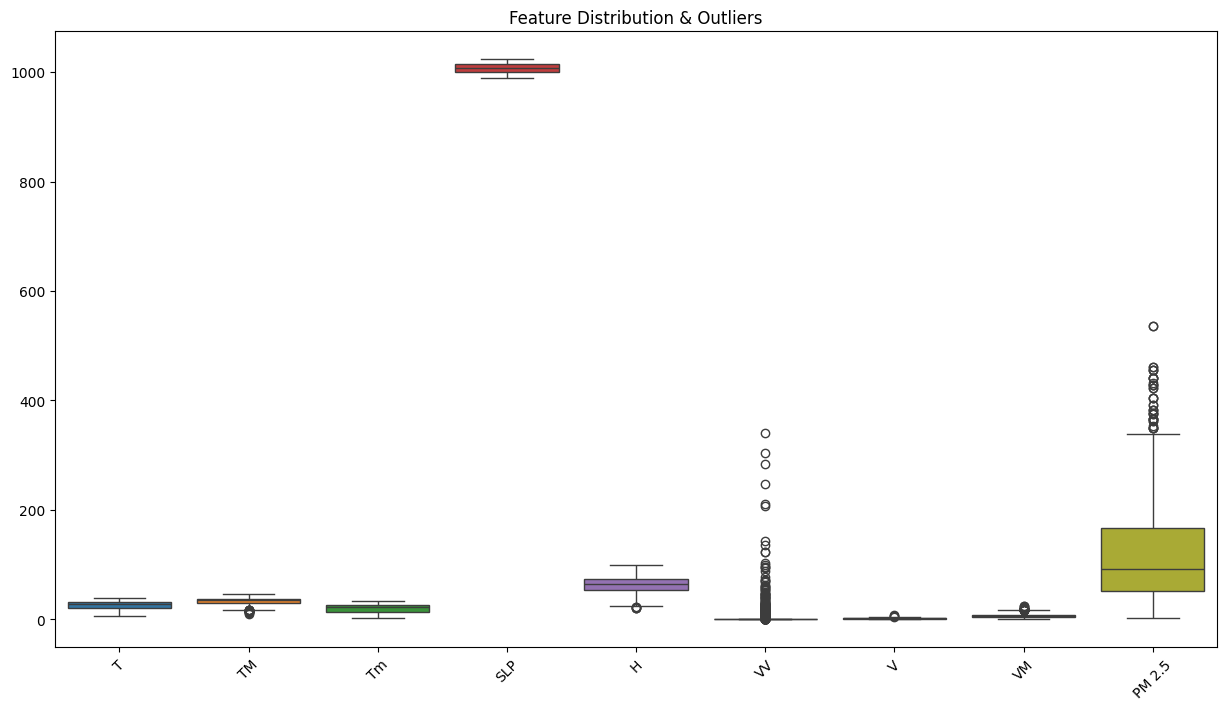

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[['T', 'TM', 'Tm', 'SLP', 'H', 'VV', 'V', 'VM', 'PM 2.5']])
plt.title('Feature Distribution & Outliers')
plt.xticks(rotation=45)
plt.show()

In [22]:
# 'VV' column mein total zero values count karein
zero_vv_count = (df['VV'] == 0).sum()
zero_vv_percent = (zero_vv_count / len(df)) * 100

print(f"Zero values in VV: {zero_vv_count} out of {len(df)} rows ({zero_vv_percent:.2f}%)")

Zero values in VV: 1793 out of 2088 rows (85.87%)


## Step 1: Cap/Remove Extreme Outliers in VV

In [15]:
# Cap VV at 99th percentile to remove extreme spikes
vv_cap = df['VV'].quantile(0.99)
df['VV'] = df['VV'].clip(upper=vv_cap)

print(f"Capped VV at 99th percentile value: {vv_cap}")

Capped VV at 99th percentile value: 63.78300000000067


## Step 2: Plot Individual Subplots (Better Scale Visibility)

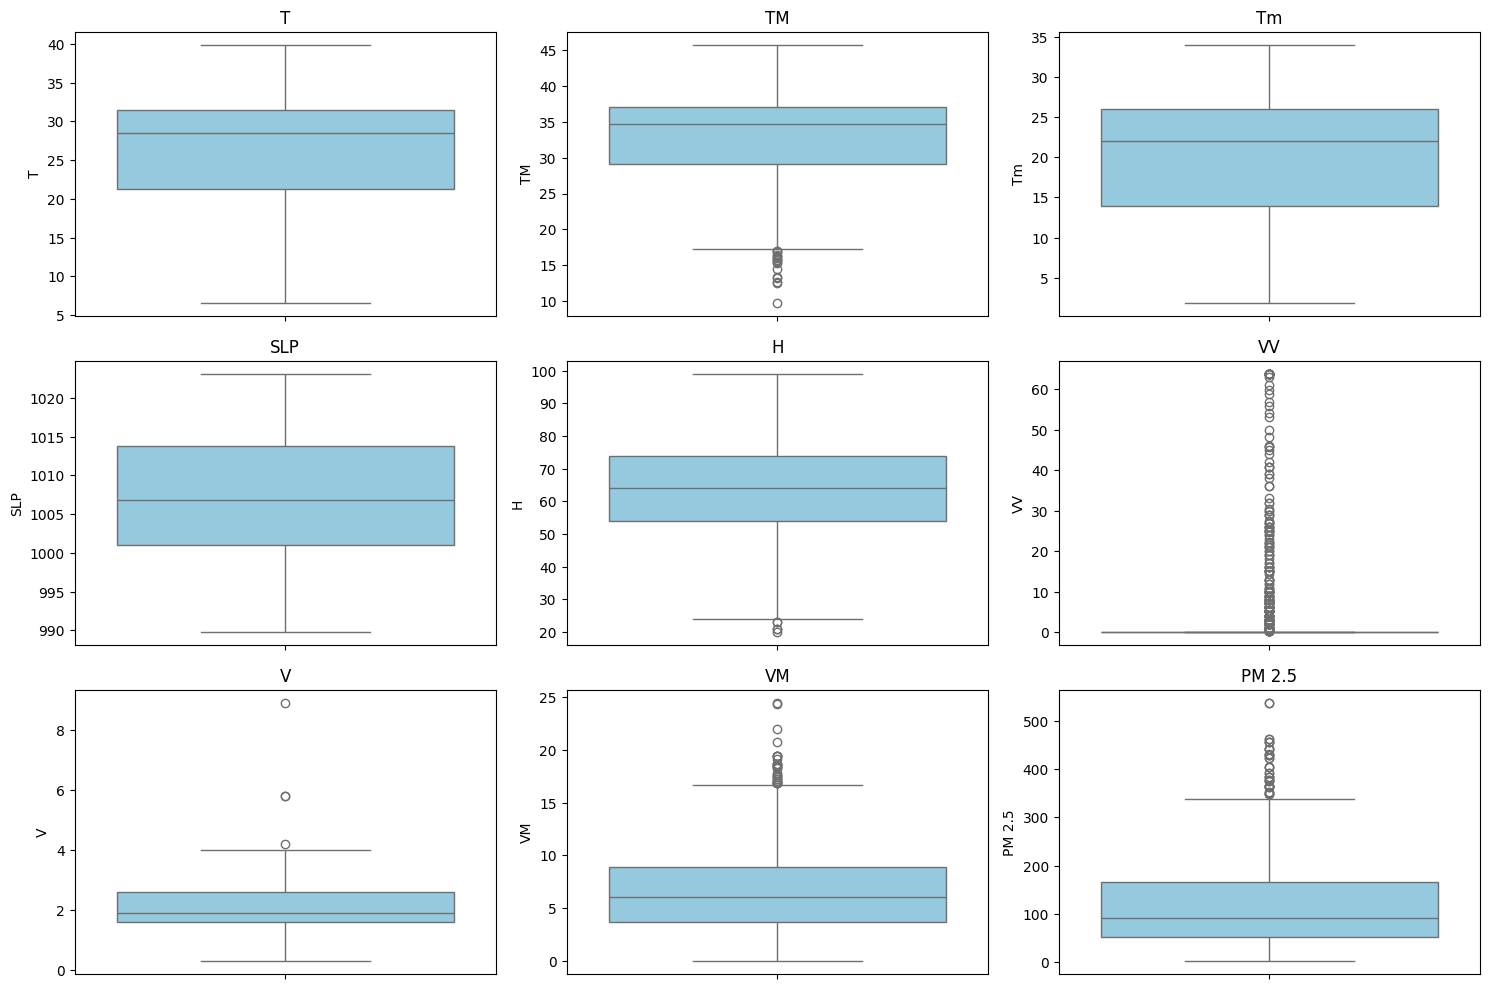

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

features = ['T', 'TM', 'Tm', 'SLP', 'H', 'VV', 'V', 'VM', 'PM 2.5']

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Feature Engineering and Training

## Step 1: Feature Capping & Train-Test Split

In [28]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Weather features par IQR Capping (Including VV, Target PM2.5 unchanged)
weather_cols = ['T', 'TM', 'Tm', 'SLP', 'H', 'VV', 'V', 'VM']
df_capped = df.copy()

for col in weather_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

# 2. Feature Engineering (Lags + Time Features)
df_capped['day_index'] = df_capped.index
df_capped['sin_day'] = np.sin(2 * np.pi * df_capped['day_index'] / 365.25)
df_capped['cos_day'] = np.cos(2 * np.pi * df_capped['day_index'] / 365.25)

df_capped['PM25_lag_1'] = df_capped['PM 2.5'].shift(1)
df_capped['PM25_lag_2'] = df_capped['PM 2.5'].shift(2)
df_capped['PM25_lag_3'] = df_capped['PM 2.5'].shift(3)
df_capped['PM25_lag_7'] = df_capped['PM 2.5'].shift(7)
df_capped['PM25_rolling7'] = df_capped['PM 2.5'].shift(1).rolling(window=7).mean()

# Drop initial NaN rows created by lags
df_capped = df_capped.dropna().reset_index(drop=True)

# 3. Feature Selection (VV IS INCLUDED)
feature_cols = ['T', 'TM', 'Tm', 'SLP', 'H', 'VV', 'V', 'VM',
                'day_index', 'sin_day', 'cos_day',
                'PM25_lag_1', 'PM25_lag_2', 'PM25_lag_3', 'PM25_lag_7', 'PM25_rolling7']

X = df_capped[feature_cols]
y = df_capped['PM 2.5']

# 4. Train-Test Split (80% Train, 20% Test - Time Series shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features count (includes VV): {X_train.shape[1]}")
print(f"X_train shape: {X_train_scaled.shape}")
print(f"X_test shape:  {X_test_scaled.shape}")

Features count (includes VV): 16
X_train shape: (1664, 16)
X_test shape:  (417, 16)


# Model : Linear Regression Train & Evaluate

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Model Fit
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Predictions
y_pred_lr_test = lr_model.predict(X_test_scaled)

# 3. Metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
r2_lr = r2_score(y_test, y_pred_lr_test)

print("=== LINEAR REGRESSION PERFORMANCE (With VV) ===")
print(f"MAE  (Mean Absolute Error): {mae_lr:.2f}")
print(f"RMSE (Root Mean Sq Error): {rmse_lr:.2f}")
print(f"R² Score:                  {r2_lr:.4f}")

=== LINEAR REGRESSION PERFORMANCE (With VV) ===
MAE  (Mean Absolute Error): 37.13
RMSE (Root Mean Sq Error): 54.62
R² Score:                  0.6619


## Comprehensive Linear Regression Plots

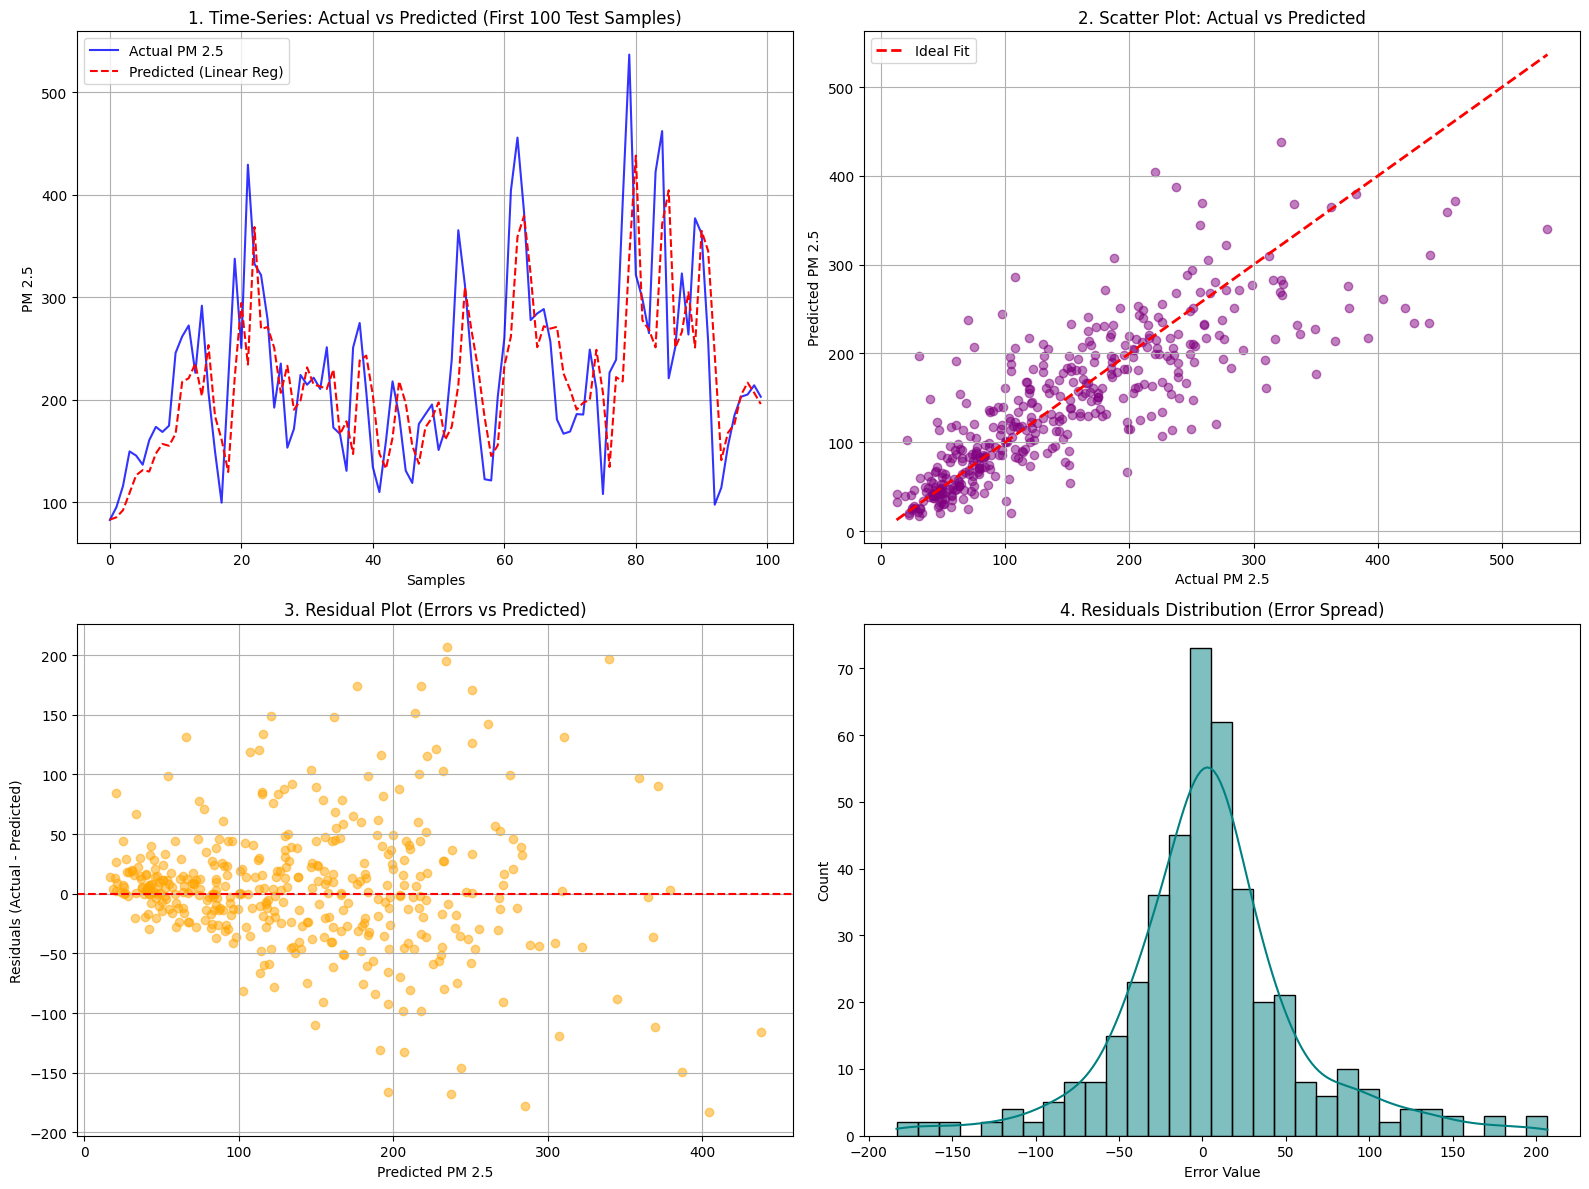

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Time-Series Line Plot (Actual vs Predicted)
axes[0, 0].plot(y_test.values[:100], label='Actual PM 2.5', color='blue', alpha=0.8)
axes[0, 0].plot(y_pred_lr_test[:100], label='Predicted (Linear Reg)', color='red', linestyle='--')
axes[0, 0].set_title('1. Time-Series: Actual vs Predicted (First 100 Test Samples)')
axes[0, 0].set_xlabel('Samples')
axes[0, 0].set_ylabel('PM 2.5')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Scatter Plot (Alignment to Ideal Line)
axes[0, 1].scatter(y_test, y_pred_lr_test, alpha=0.5, color='purple')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
axes[0, 1].set_title('2. Scatter Plot: Actual vs Predicted')
axes[0, 1].set_xlabel('Actual PM 2.5')
axes[0, 1].set_ylabel('Predicted PM 2.5')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. Residual Plot (Checking Non-Linearities)
residuals_lr = y_test - y_pred_lr_test
axes[1, 0].scatter(y_pred_lr_test, residuals_lr, alpha=0.5, color='orange')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('3. Residual Plot (Errors vs Predicted)')
axes[1, 0].set_xlabel('Predicted PM 2.5')
axes[1, 0].set_ylabel('Residuals (Actual - Predicted)')
axes[1, 0].grid(True)

# 4. Error Distribution
sns.histplot(residuals_lr, kde=True, ax=axes[1, 1], color='teal')
axes[1, 1].set_title('4. Residuals Distribution (Error Spread)')
axes[1, 1].set_xlabel('Error Value')

plt.tight_layout()
plt.show()

# Model : Decision Tree Regressor

In [31]:
from sklearn.tree import DecisionTreeRegressor

# 1. Model Fit
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred_dt = dt_model.predict(X_test_scaled)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("=== DECISION TREE PERFORMANCE ===")
print(f"MAE:  {mae_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")
print(f"R² Score: {r2_dt:.4f}")

=== DECISION TREE PERFORMANCE ===
MAE:  38.04
RMSE: 56.99
R² Score: 0.6320


## Decision Tree Performance & Feature Importance Plots

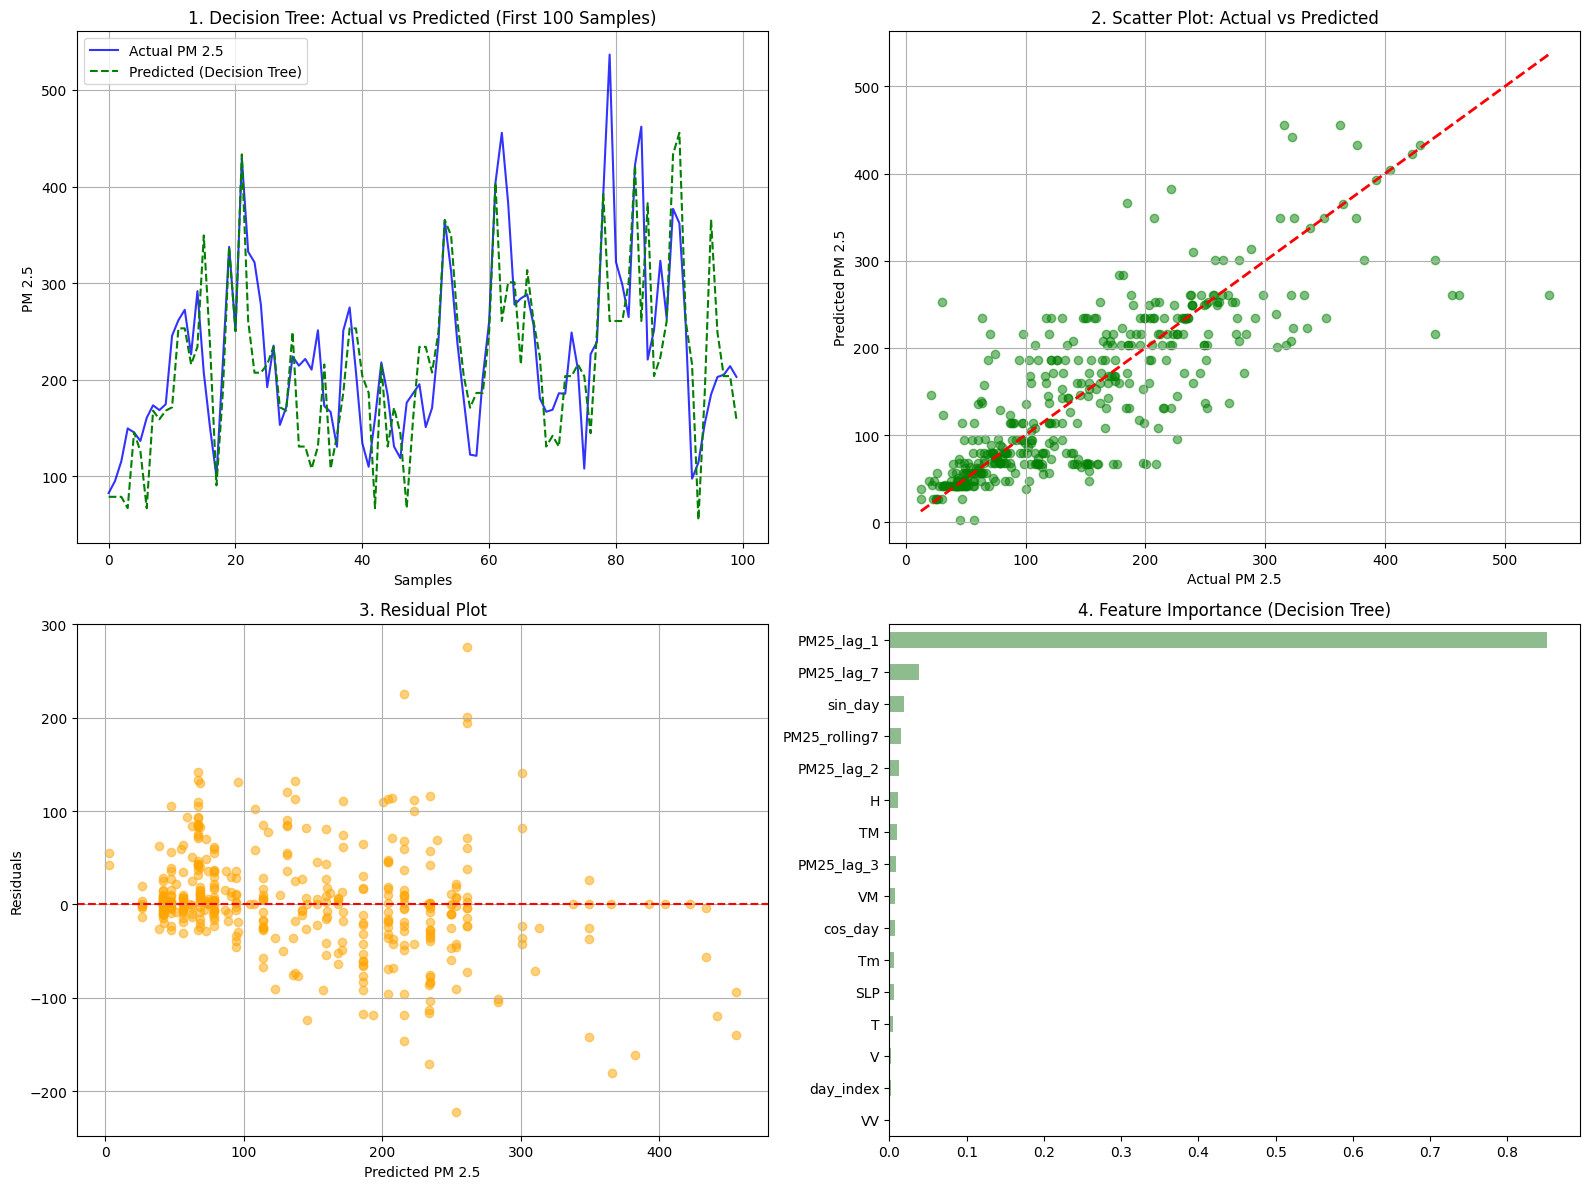

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Time-Series Plot
axes[0, 0].plot(y_test.values[:100], label='Actual PM 2.5', color='blue', alpha=0.8)
axes[0, 0].plot(y_pred_dt[:100], label='Predicted (Decision Tree)', color='green', linestyle='--')
axes[0, 0].set_title('1. Decision Tree: Actual vs Predicted (First 100 Samples)')
axes[0, 0].set_xlabel('Samples')
axes[0, 0].set_ylabel('PM 2.5')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Scatter Plot
axes[0, 1].scatter(y_test, y_pred_dt, alpha=0.5, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('2. Scatter Plot: Actual vs Predicted')
axes[0, 1].set_xlabel('Actual PM 2.5')
axes[0, 1].set_ylabel('Predicted PM 2.5')
axes[0, 1].grid(True)

# 3. Residual Plot
residuals_dt = y_test - y_pred_dt
axes[1, 0].scatter(y_pred_dt, residuals_dt, alpha=0.5, color='orange')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('3. Residual Plot')
axes[1, 0].set_xlabel('Predicted PM 2.5')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True)

# 4. Feature Importances
importances_dt = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances_dt.plot(kind='barh', ax=axes[1, 1], color='darkseagreen')
axes[1, 1].set_title('4. Feature Importance (Decision Tree)')

plt.tight_layout()
plt.show()

# Model: Random Forest Regressor

In [33]:
from sklearn.ensemble import RandomForestRegressor

# 1. Model Fit
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred_rf = rf_model.predict(X_test_scaled)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=== RANDOM FOREST PERFORMANCE ===")
print(f"MAE:  {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R² Score: {r2_rf:.4f}")

=== RANDOM FOREST PERFORMANCE ===
MAE:  28.77
RMSE: 42.77
R² Score: 0.7927


## Random Forest Plots

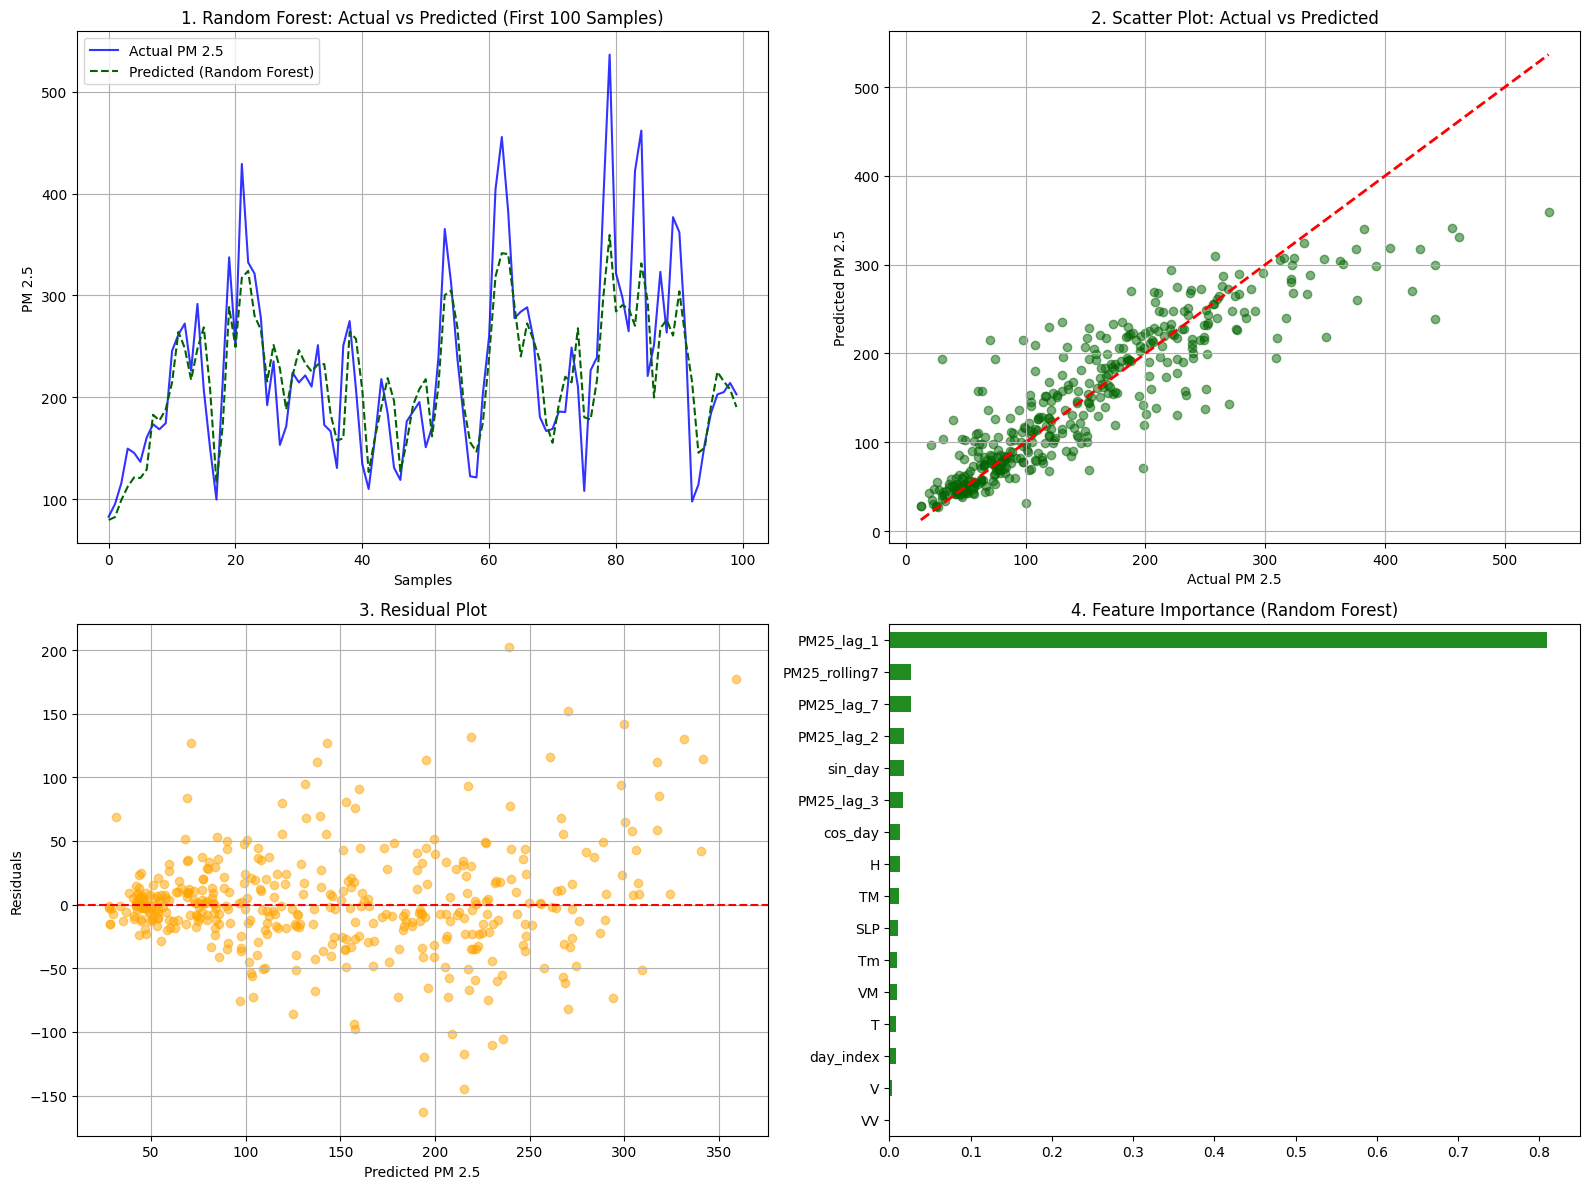

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Time-Series Plot
axes[0, 0].plot(y_test.values[:100], label='Actual PM 2.5', color='blue', alpha=0.8)
axes[0, 0].plot(y_pred_rf[:100], label='Predicted (Random Forest)', color='darkgreen', linestyle='--')
axes[0, 0].set_title('1. Random Forest: Actual vs Predicted (First 100 Samples)')
axes[0, 0].set_xlabel('Samples')
axes[0, 0].set_ylabel('PM 2.5')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Scatter Plot
axes[0, 1].scatter(y_test, y_pred_rf, alpha=0.5, color='darkgreen')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('2. Scatter Plot: Actual vs Predicted')
axes[0, 1].set_xlabel('Actual PM 2.5')
axes[0, 1].set_ylabel('Predicted PM 2.5')
axes[0, 1].grid(True)

# 3. Residual Plot
residuals_rf = y_test - y_pred_rf
axes[1, 0].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='orange')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('3. Residual Plot')
axes[1, 0].set_xlabel('Predicted PM 2.5')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True)

# 4. Feature Importances
importances_rf = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances_rf.plot(kind='barh', ax=axes[1, 1], color='forestgreen')
axes[1, 1].set_title('4. Feature Importance (Random Forest)')

plt.tight_layout()
plt.show()

# Model: Gradient Boosting Regressor (GBM)

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

# 1. Model Fit
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# 2. Predictions & Metrics
y_pred_gb = gb_model.predict(X_test_scaled)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("=== GRADIENT BOOSTING PERFORMANCE ===")
print(f"MAE:  {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")
print(f"R² Score: {r2_gb:.4f}")

=== GRADIENT BOOSTING PERFORMANCE ===
MAE:  28.08
RMSE: 41.08
R² Score: 0.8087


## Gradient Boosting Plots

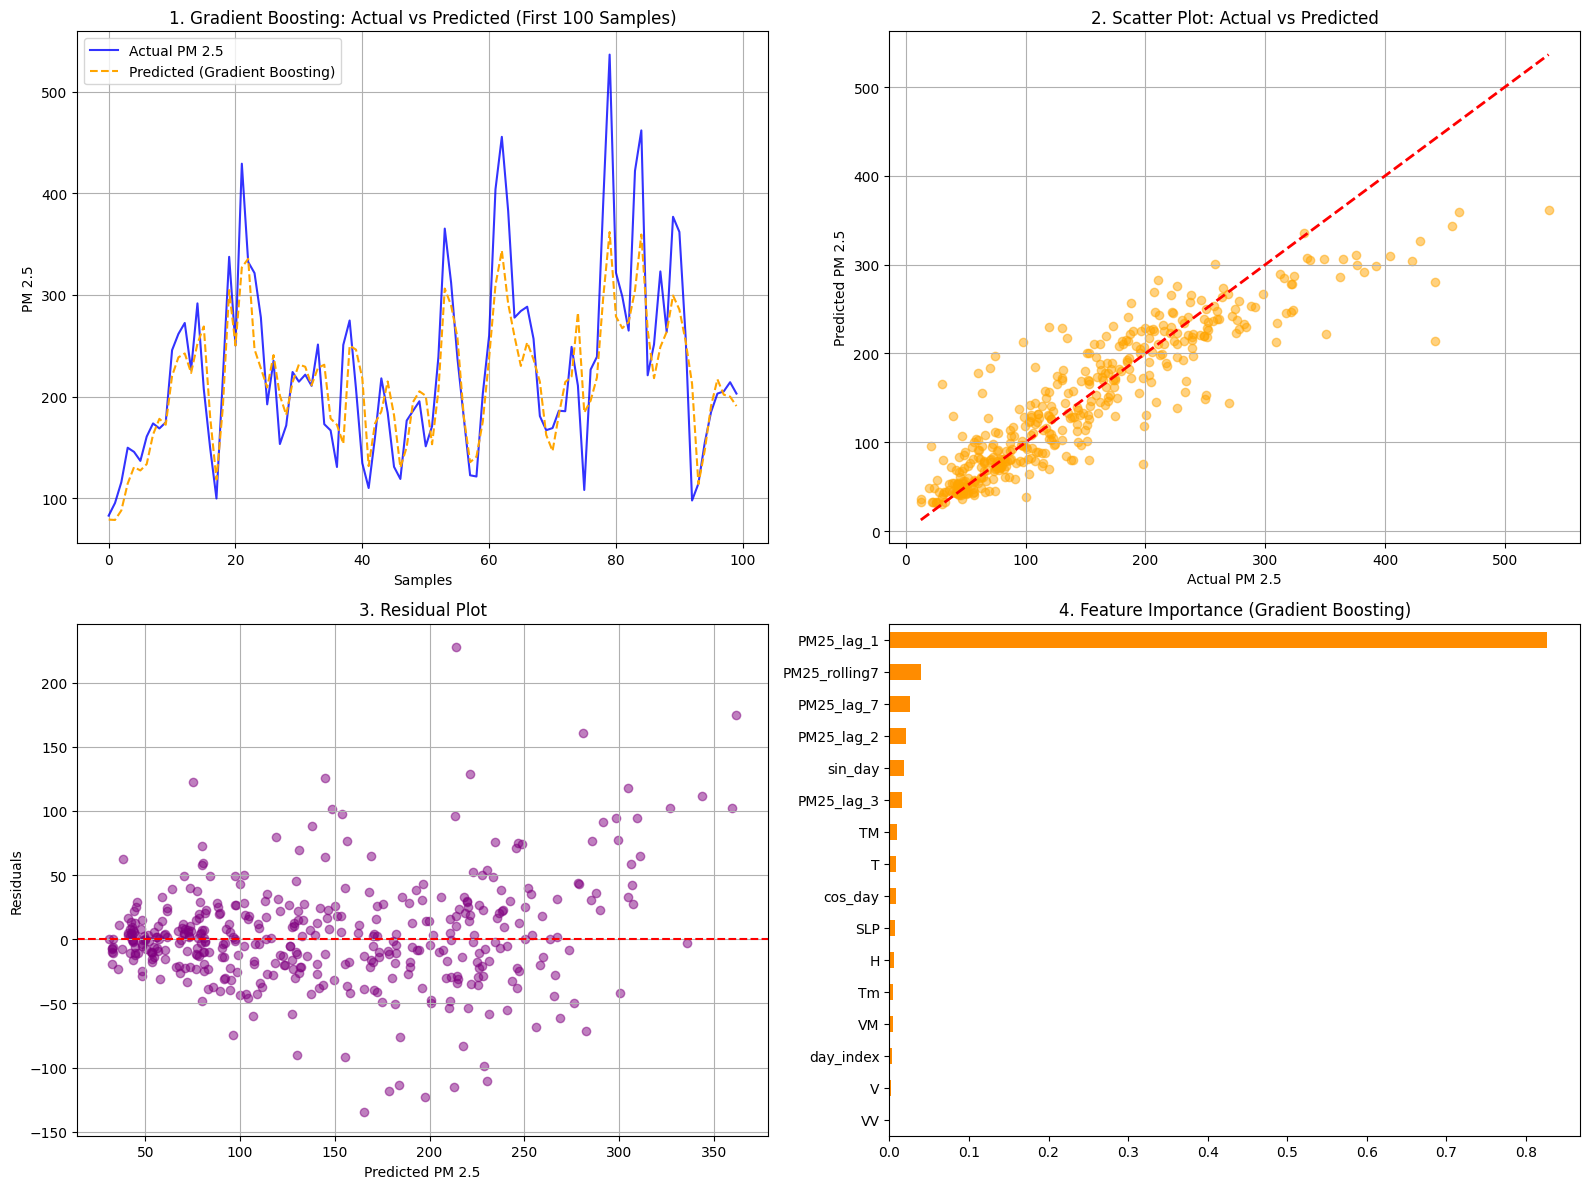

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Time-Series Plot
axes[0, 0].plot(y_test.values[:100], label='Actual PM 2.5', color='blue', alpha=0.8)
axes[0, 0].plot(y_pred_gb[:100], label='Predicted (Gradient Boosting)', color='orange', linestyle='--')
axes[0, 0].set_title('1. Gradient Boosting: Actual vs Predicted (First 100 Samples)')
axes[0, 0].set_xlabel('Samples')
axes[0, 0].set_ylabel('PM 2.5')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Scatter Plot
axes[0, 1].scatter(y_test, y_pred_gb, alpha=0.5, color='orange')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('2. Scatter Plot: Actual vs Predicted')
axes[0, 1].set_xlabel('Actual PM 2.5')
axes[0, 1].set_ylabel('Predicted PM 2.5')
axes[0, 1].grid(True)

# 3. Residual Plot
residuals_gb = y_test - y_pred_gb
axes[1, 0].scatter(y_pred_gb, residuals_gb, alpha=0.5, color='purple')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('3. Residual Plot')
axes[1, 0].set_xlabel('Predicted PM 2.5')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True)

# 4. Feature Importances
importances_gb = pd.Series(gb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances_gb.plot(kind='barh', ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('4. Feature Importance (Gradient Boosting)')

plt.tight_layout()
plt.show()

# Models: XGBoost & Support Vector Regressor (SVR)

In [37]:
from xgboost import XGBRegressor
from sklearn.svm import SVR

# 1. XGBoost Model Training
xgb_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03, random_state=42)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

# 2. SVR Model Training
svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("=== XGBOOST PERFORMANCE ===")
print(f"MAE:  {mae_xgb:.2f} | RMSE: {rmse_xgb:.2f} | R² Score: {r2_xgb:.4f}")

print("\n=== SUPPORT VECTOR REGRESSOR (SVR) PERFORMANCE ===")
print(f"MAE:  {mae_svr:.2f} | RMSE: {rmse_svr:.2f} | R² Score: {r2_svr:.4f}")

=== XGBOOST PERFORMANCE ===
MAE:  27.46 | RMSE: 41.22 | R² Score: 0.8074

=== SUPPORT VECTOR REGRESSOR (SVR) PERFORMANCE ===
MAE:  37.97 | RMSE: 57.46 | R² Score: 0.6258


## XGBoost Performance Plots

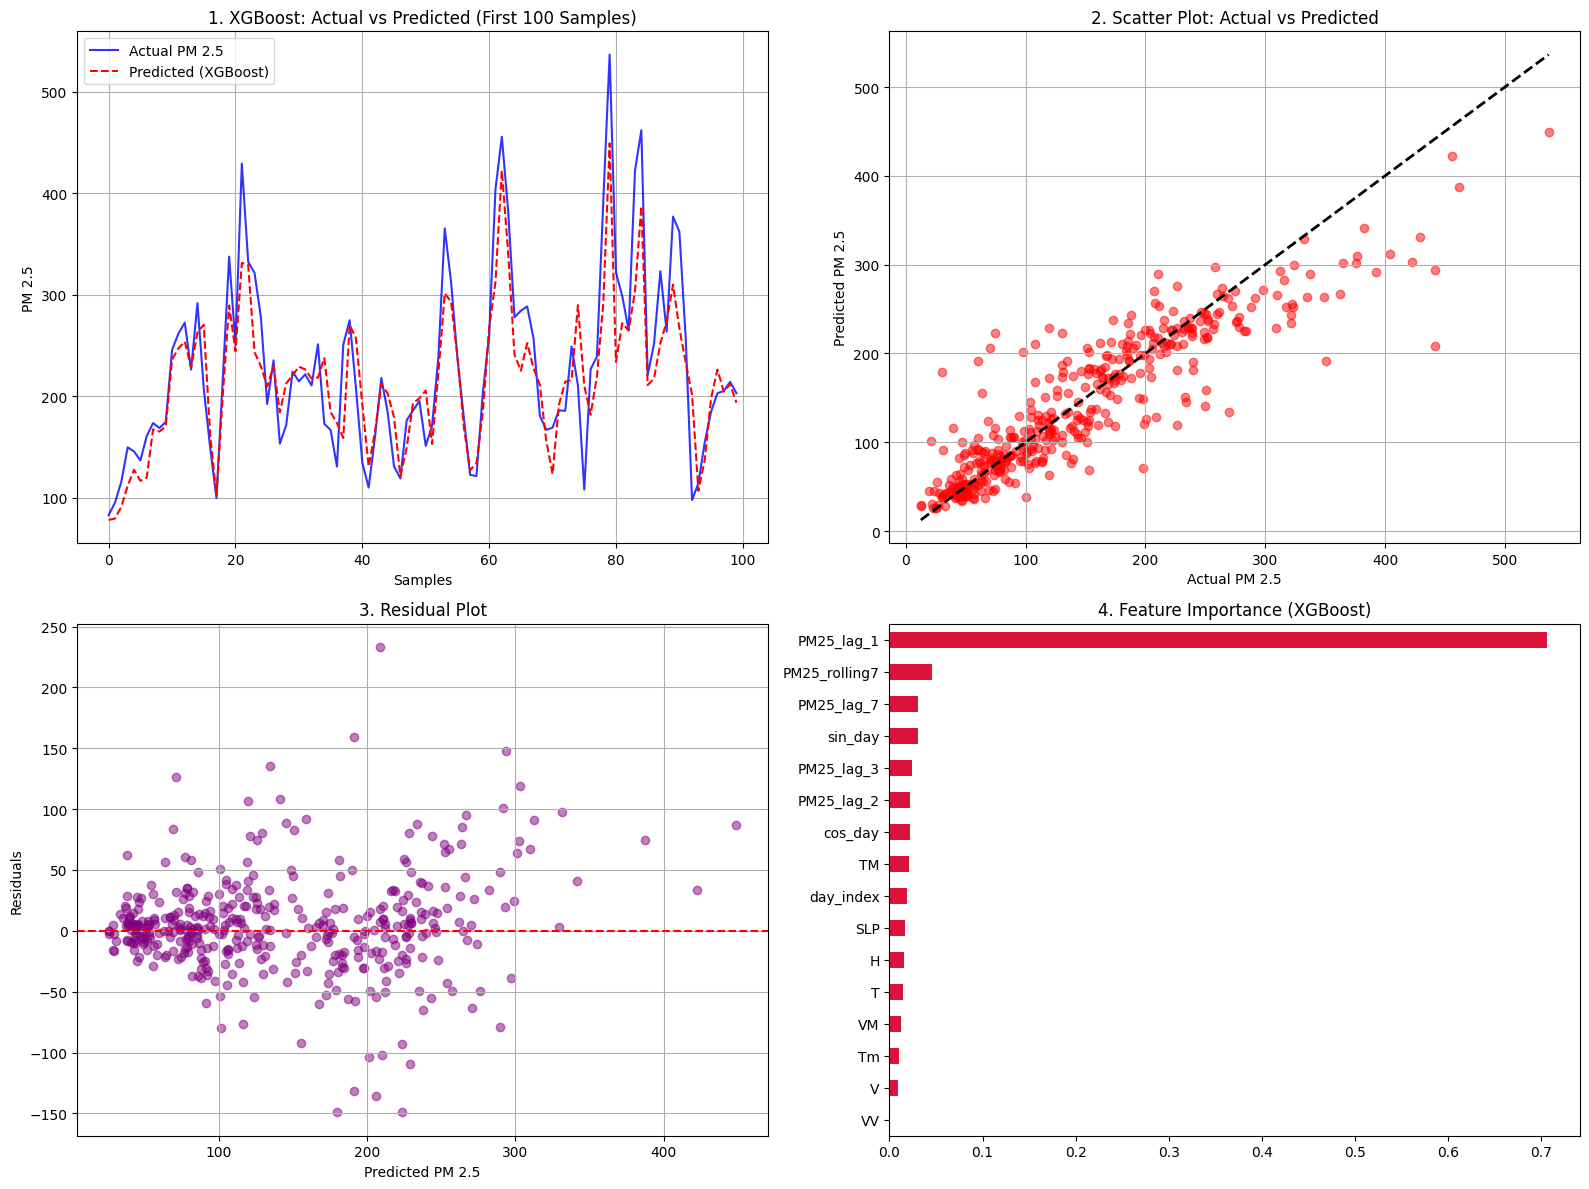

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Time-Series Plot
axes[0, 0].plot(y_test.values[:100], label='Actual PM 2.5', color='blue', alpha=0.8)
axes[0, 0].plot(y_pred_xgb[:100], label='Predicted (XGBoost)', color='red', linestyle='--')
axes[0, 0].set_title('1. XGBoost: Actual vs Predicted (First 100 Samples)')
axes[0, 0].set_xlabel('Samples')
axes[0, 0].set_ylabel('PM 2.5')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Scatter Plot
axes[0, 1].scatter(y_test, y_pred_xgb, alpha=0.5, color='red')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0, 1].set_title('2. Scatter Plot: Actual vs Predicted')
axes[0, 1].set_xlabel('Actual PM 2.5')
axes[0, 1].set_ylabel('Predicted PM 2.5')
axes[0, 1].grid(True)

# 3. Residual Plot
residuals_xgb = y_test - y_pred_xgb
axes[1, 0].scatter(y_pred_xgb, residuals_xgb, alpha=0.5, color='purple')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('3. Residual Plot')
axes[1, 0].set_xlabel('Predicted PM 2.5')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True)

# 4. Feature Importances
importances_xgb = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
importances_xgb.plot(kind='barh', ax=axes[1, 1], color='crimson')
axes[1, 1].set_title('4. Feature Importance (XGBoost)')

plt.tight_layout()
plt.show()

# All Models Comparison Table & Summary Chart

=== ALL MODELS PERFORMANCE COMPARISON ===


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,28.076133,41.082678,0.808748
1,XGBoost,27.457248,41.223792,0.807431
2,Random Forest,28.774449,42.768731,0.792727
3,Linear Regression,37.130594,54.620639,0.661933
4,Decision Tree,38.038443,56.987580,0.631998
5,SVR,37.972435,57.462653,0.625837


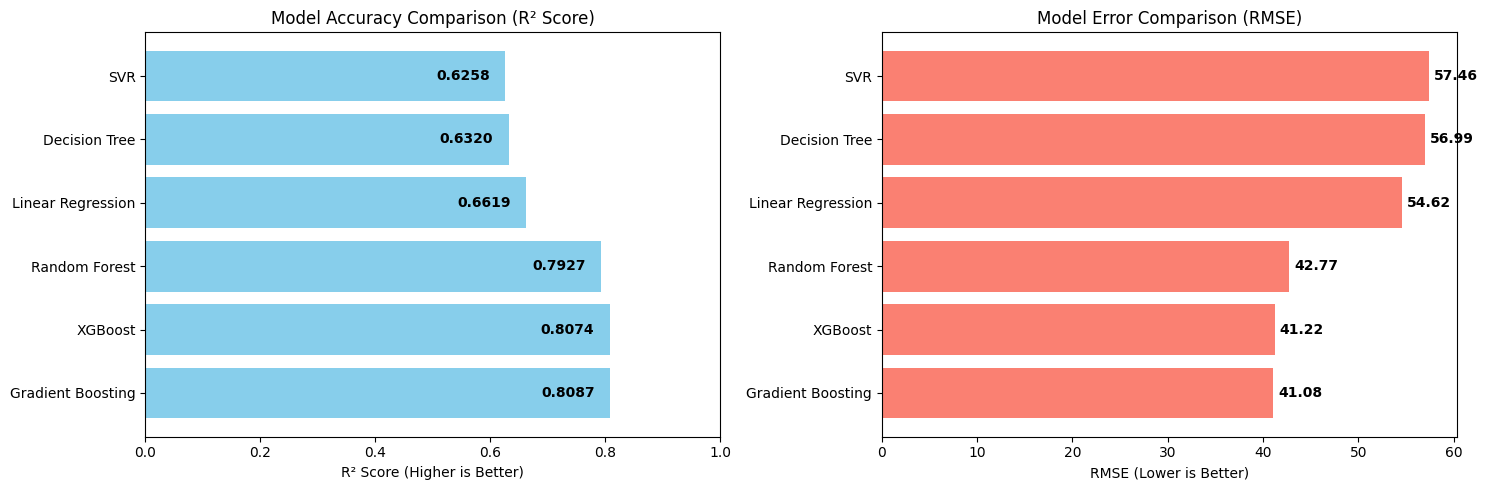

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

# Comparison Dataframe
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'SVR'],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_gb, mae_xgb, mae_svr],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_gb, rmse_xgb, rmse_svr],
    'R2 Score': [r2_lr, r2_dt, r2_rf, r2_gb, r2_xgb, r2_svr]
}).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("=== ALL MODELS PERFORMANCE COMPARISON ===")
display(results_df)

# Visualizing Model Comparison
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# R2 Score Comparison
ax[0].barh(results_df['Model'], results_df['R2 Score'], color='skyblue')
ax[0].set_xlabel('R² Score (Higher is Better)')
ax[0].set_title('Model Accuracy Comparison (R² Score)')
ax[0].set_xlim([0, 1])

for index, value in enumerate(results_df['R2 Score']):
    ax[0].text(value - 0.12, index, f"{value:.4f}", color='black', fontweight='bold', va='center')

# RMSE Comparison
ax[1].barh(results_df['Model'], results_df['RMSE'], color='salmon')
ax[1].set_xlabel('RMSE (Lower is Better)')
ax[1].set_title('Model Error Comparison (RMSE)')

for index, value in enumerate(results_df['RMSE']):
    ax[1].text(value + 0.5, index, f"{value:.2f}", color='black', fontweight='bold', va='center')

plt.tight_layout()
plt.show()

## Plot 1: Models Performance Comparison Bar Chart ($R^2$ Score & RMSE)

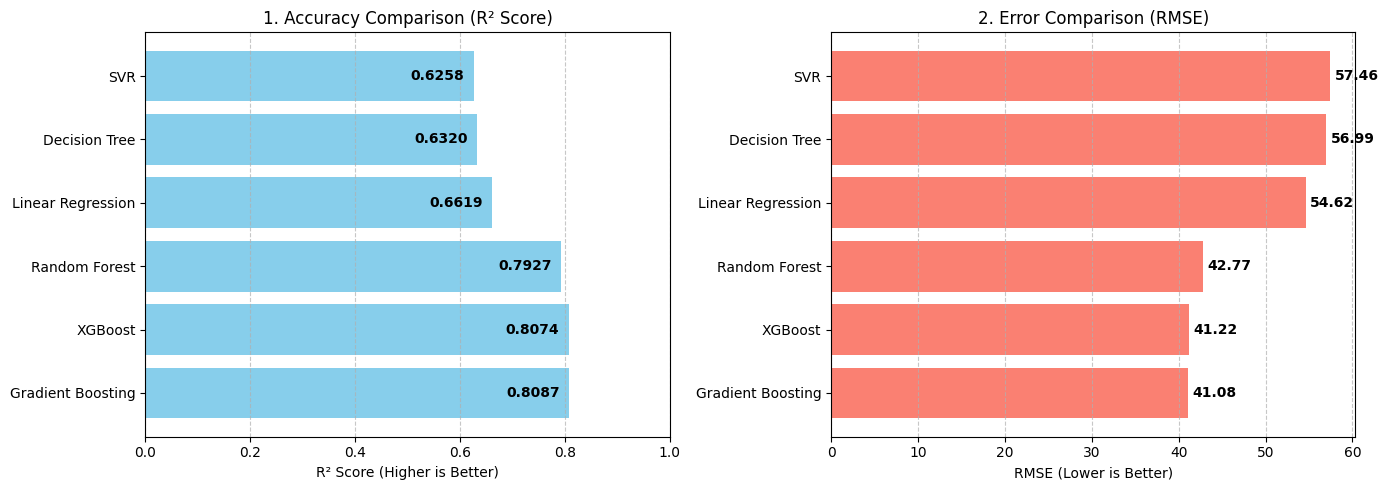

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# Subplot 1: R2 Score Comparison
plt.subplot(1, 2, 1)
bars1 = plt.barh(results_df['Model'], results_df['R2 Score'], color='skyblue')
plt.xlabel('R² Score (Higher is Better)')
plt.title('1. Accuracy Comparison (R² Score)')
plt.xlim([0, 1])
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars1:
    width = bar.get_width()
    plt.text(width - 0.12, bar.get_y() + bar.get_height()/2, f'{width:.4f}',
             va='center', color='black', fontweight='bold')

# Subplot 2: RMSE Comparison
plt.subplot(1, 2, 2)
bars2 = plt.barh(results_df['Model'], results_df['RMSE'], color='salmon')
plt.xlabel('RMSE (Lower is Better)')
plt.title('2. Error Comparison (RMSE)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar in bars2:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
             va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

## Plot 2: Time-Series Line Plot (Actual vs Predictions of Top Models)

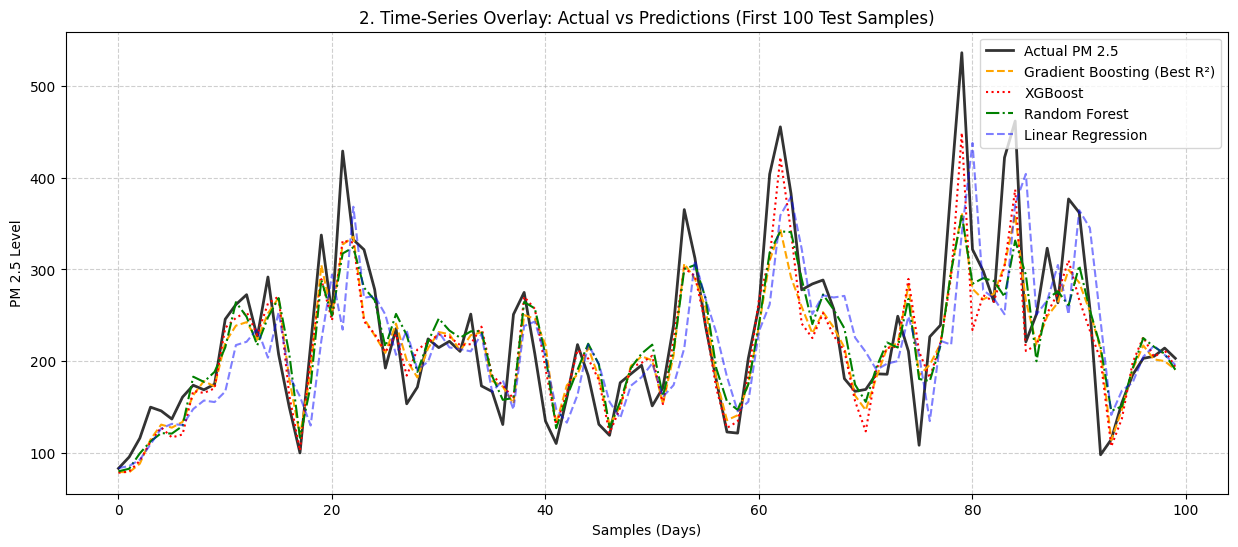

In [41]:
plt.figure(figsize=(15, 6))

# Actual Target
plt.plot(y_test.values[:100], label='Actual PM 2.5', color='black', linewidth=2, alpha=0.8)

# Top Models Predictions
plt.plot(y_pred_gb[:100], label='Gradient Boosting (Best R²)', color='orange', linestyle='--')
plt.plot(y_pred_xgb[:100], label='XGBoost', color='red', linestyle=':')
plt.plot(y_pred_rf[:100], label='Random Forest', color='green', linestyle='-.')
plt.plot(y_pred_lr_test[:100], label='Linear Regression', color='blue', linestyle='--', alpha=0.5)

plt.title('2. Time-Series Overlay: Actual vs Predictions (First 100 Test Samples)')
plt.xlabel('Samples (Days)')
plt.ylabel('PM 2.5 Level')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Plot 3: Scatter Plots Grid (Actual vs Predicted Across Models)

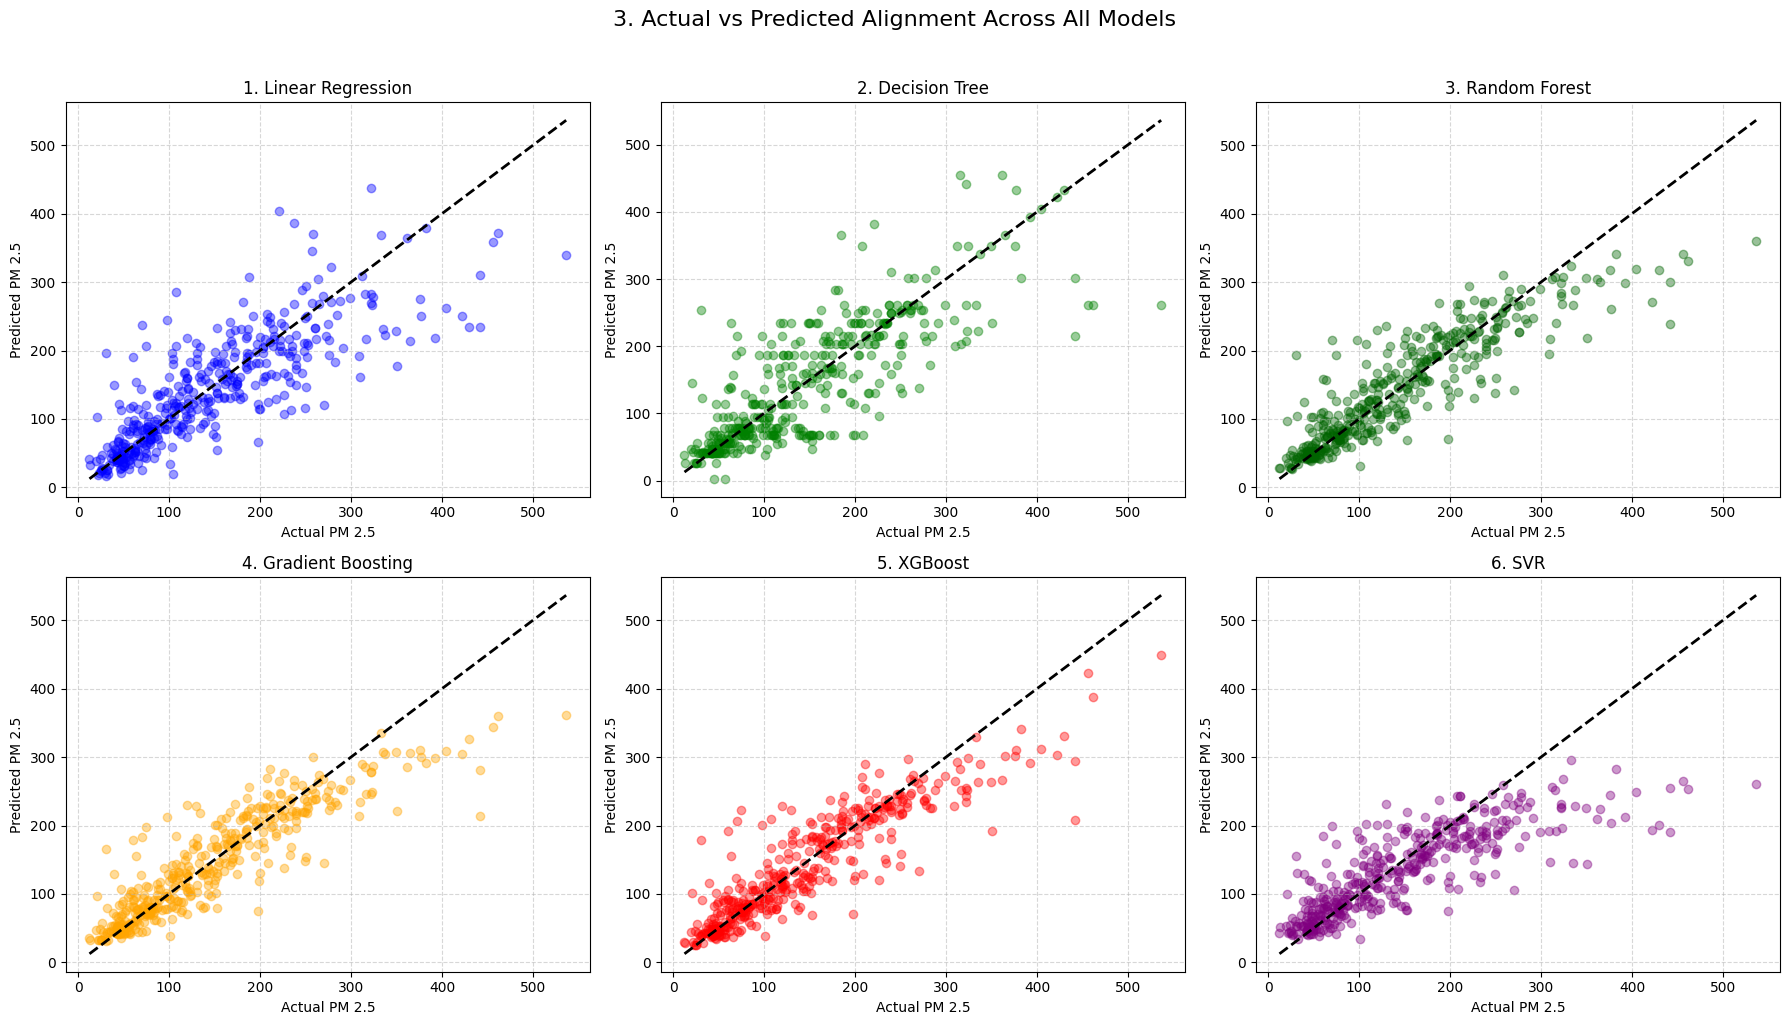

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

models_preds = [
    ('Linear Regression', y_pred_lr_test, 'blue'),
    ('Decision Tree', y_pred_dt, 'green'),
    ('Random Forest', y_pred_rf, 'darkgreen'),
    ('Gradient Boosting', y_pred_gb, 'orange'),
    ('XGBoost', y_pred_xgb, 'red'),
    ('SVR', y_pred_svr, 'purple')
]

for idx, (name, preds, color) in enumerate(models_preds):
    axes[idx].scatter(y_test, preds, alpha=0.4, color=color)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    axes[idx].set_title(f'{idx+1}. {name}')
    axes[idx].set_xlabel('Actual PM 2.5')
    axes[idx].set_ylabel('Predicted PM 2.5')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('3. Actual vs Predicted Alignment Across All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Plot 4: Residuals (Error Distribution) Comparison

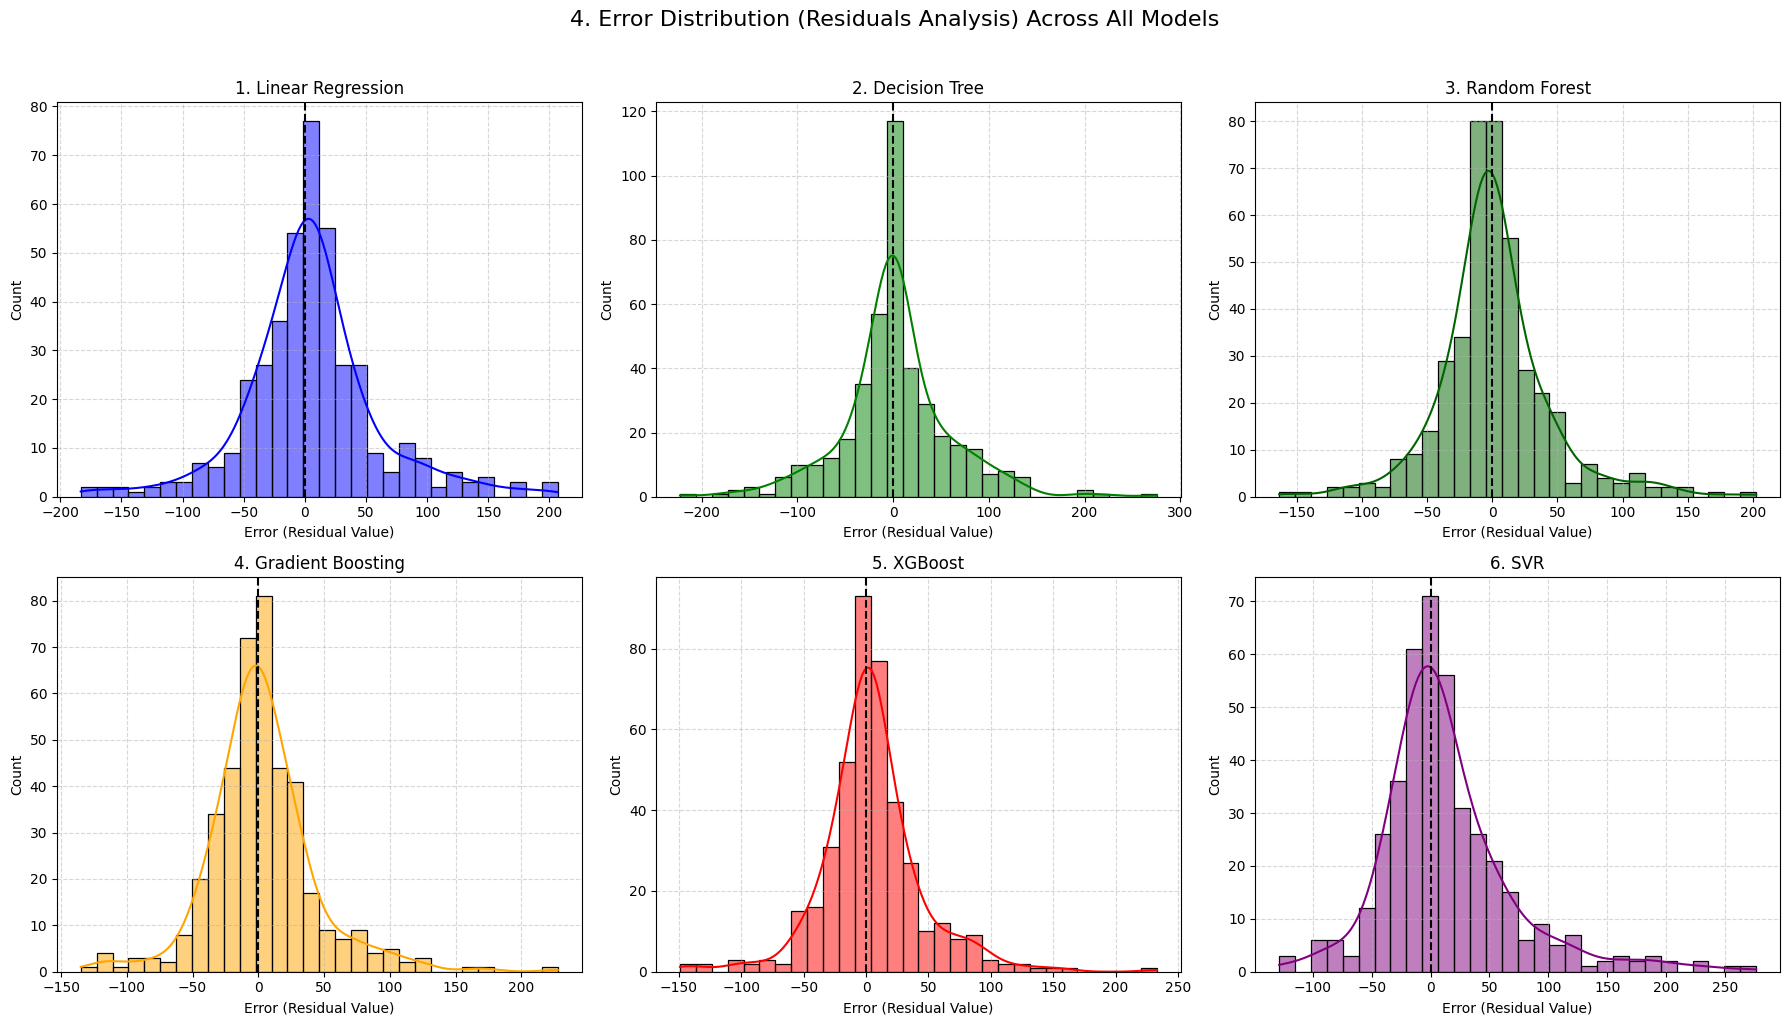

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

models_residuals = [
    ('Linear Regression', y_test - y_pred_lr_test, 'blue'),
    ('Decision Tree', y_test - y_pred_dt, 'green'),
    ('Random Forest', y_test - y_pred_rf, 'darkgreen'),
    ('Gradient Boosting', y_test - y_pred_gb, 'orange'),
    ('XGBoost', y_test - y_pred_xgb, 'red'),
    ('SVR', y_test - y_pred_svr, 'purple')
]

for idx, (name, res, color) in enumerate(models_residuals):
    sns.histplot(res, kde=True, ax=axes[idx], color=color, bins=30)
    axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=1.5)
    axes[idx].set_title(f'{idx+1}. {name}')
    axes[idx].set_xlabel('Error (Residual Value)')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('4. Error Distribution (Residuals Analysis) Across All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Plot 5: Feature Importances Comparison (Tree-Based Models)

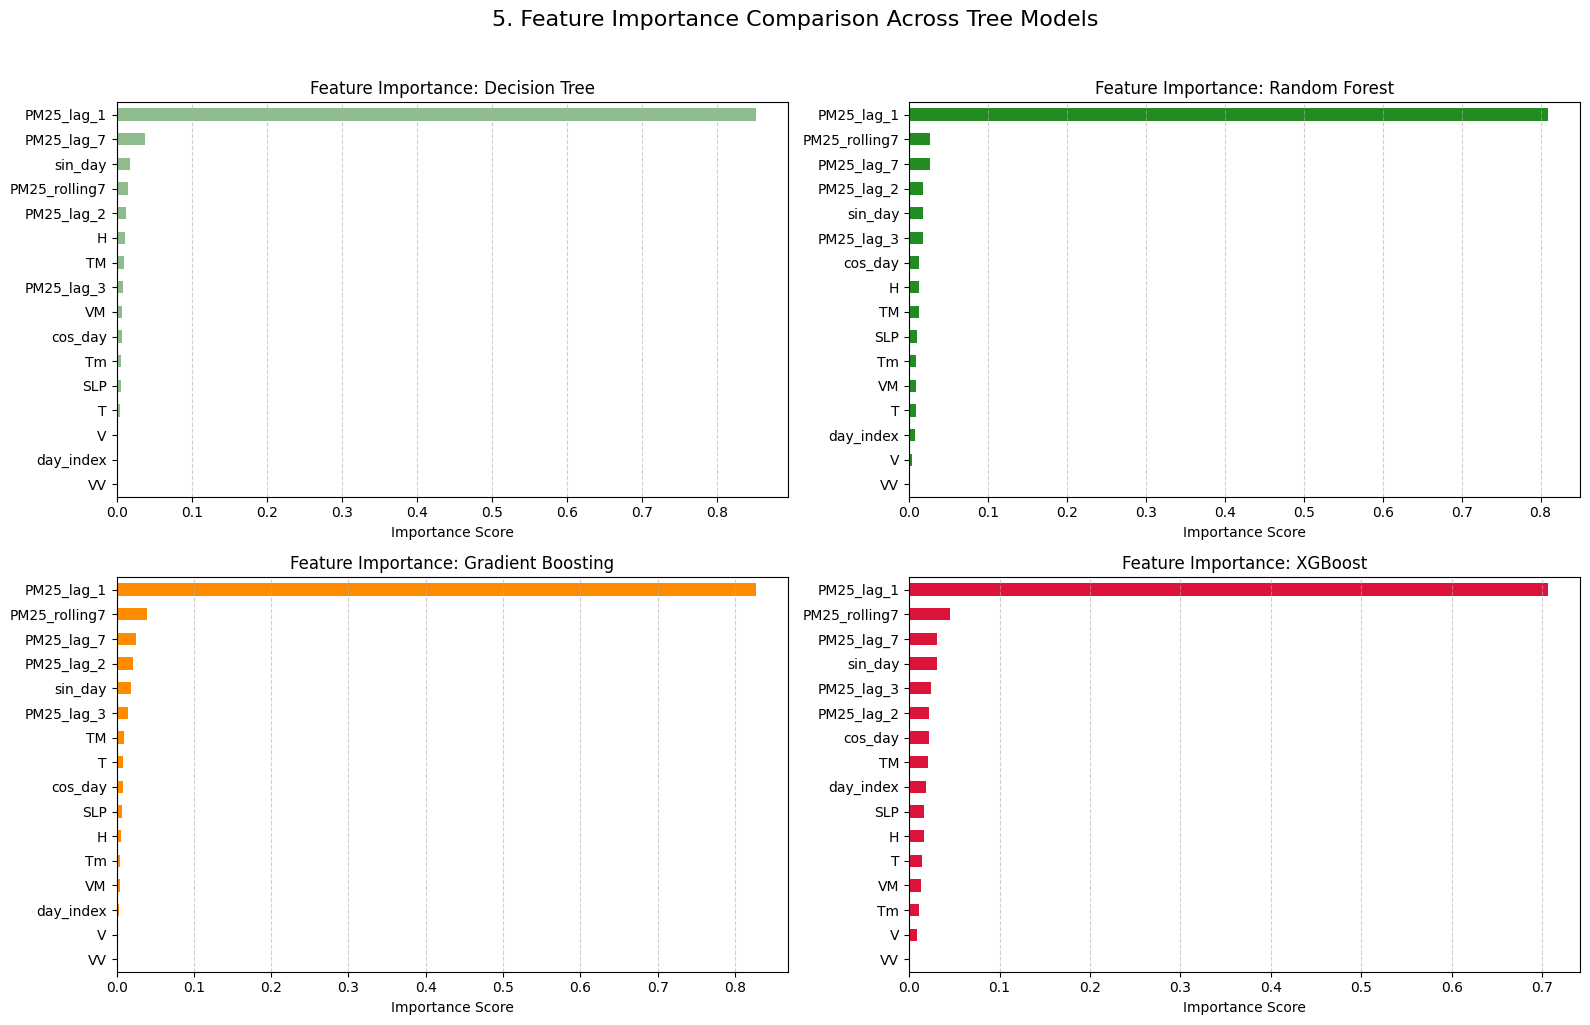

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

tree_models = [
    ('Decision Tree', dt_model, 'darkseagreen', axes[0, 0]),
    ('Random Forest', rf_model, 'forestgreen', axes[0, 1]),
    ('Gradient Boosting', gb_model, 'darkorange', axes[1, 0]),
    ('XGBoost', xgb_model, 'crimson', axes[1, 1])
]

for name, model, color, ax in tree_models:
    importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Feature Importance: {name}')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('5. Feature Importance Comparison Across Tree Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ALL MODELS PERFORMANCE COMPARISON METRICS TABLE

In [46]:
import pandas as pd

# 1. Models Summary Data
summary_data = {
    'Model Name': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'Support Vector Regressor (SVR)'
    ],
    'MAE (Lower Better)': [mae_lr, mae_dt, mae_rf, mae_gb, mae_xgb, mae_svr],
    'RMSE (Lower Better)': [rmse_lr, rmse_dt, rmse_rf, rmse_gb, rmse_xgb, rmse_svr],
    'R² Score (Higher Better)': [r2_lr, r2_dt, r2_rf, r2_gb, r2_xgb, r2_svr]
}

# DataFrame Banayein aur R2 Score par Sort Karein
comparison_df = pd.DataFrame(summary_data).sort_values(by='R² Score (Higher Better)', ascending=False).reset_index(drop=True)

# 2. Styling Function: Best Model Row ko Green Highlight Karne ke Liye
def highlight_best(row):
    # Top ranked model ko highlight karein (R2 Score highest)
    if row['Model Name'] == comparison_df.iloc[0]['Model Name']:
        return ['background-color: #d4edda; color: #155724; font-weight: bold'] * len(row)
    return [''] * len(row)

# Table Styling Apply Karein
styled_table = comparison_df.style\
    .apply(highlight_best, axis=1)\
    .format({'MAE (Lower Better)': '{:.2f}', 'RMSE (Lower Better)': '{:.2f}', 'R² Score (Higher Better)': '{:.4f}'})\
    .set_caption("<b>ALL MODELS PERFORMANCE COMPARISON METRICS TABLE</b>")

# Render Styled Table
display(styled_table)

,Model Name,MAE (Lower Better),RMSE (Lower Better),R² Score (Higher Better)
0,Gradient Boosting,28.08,41.08,0.8087
1,XGBoost,27.46,41.22,0.8074
2,Random Forest,28.77,42.77,0.7927
3,Linear Regression,37.13,54.62,0.6619
4,Decision Tree,38.04,56.99,0.6320
5,Support Vector Regressor (SVR),37.97,57.46,0.6258


## Model Export

In [45]:
import joblib

# 1. Best Model Save Karein
joblib.dump(gb_model, 'best_pm25_gb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler successfully saved!")

# 2. Google Colab se Download karne ke liye (Optional):
from google.colab import files
files.download('best_pm25_gb_model.pkl')
files.download('scaler.pkl')

Model and Scaler successfully saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 1. Hyperparameter Tuning (Sabse Fast & Effective Step)

In [49]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# 1. Parameter Grid Setup
param_grid = {
    'n_estimators': [100, 200, 300, 500, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.02, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5]
}

# 2. RandomizedSearch with VERBOSE=2 (Live Logs dikhenge!)
xgb_base = XGBRegressor(random_state=42)
search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=25,
    cv=5,
    scoring='r2',
    verbose=2,          # <--- Ye live output/progress print karega!
    random_state=42,
    n_jobs=-1
)

print("Starting Hyperparameter Tuning...")
search.fit(X_train_scaled, y_train)

# 3. Best Model & Evaluation
best_xgb = search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test_scaled)

r2_tuned = r2_score(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print("\n=== HYPERPARAMETER TUNED XGBOOST RESULTS ===")
print("Best Parameters:", search.best_params_)
print(f"Test MAE:       {mae_tuned:.2f}")
print(f"Test RMSE:      {rmse_tuned:.2f}")
print(f"Test R² Score:  {r2_tuned:.4f}")


Starting Hyperparameter Tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

=== HYPERPARAMETER TUNED XGBOOST RESULTS ===
Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Test MAE:       28.34
Test RMSE:      42.79
Test R² Score:  0.7925


## Feature Engineering 2.0

In [50]:
# 1. New Features Create Karein
df_feat = df_capped.copy()

# Advanced Lags & Rolling
df_feat['PM25_lag_14'] = df_feat['PM 2.5'].shift(14)
df_feat['PM25_lag_30'] = df_feat['PM 2.5'].shift(30)
df_feat['PM25_rolling3'] = df_feat['PM 2.5'].shift(1).rolling(window=3).mean()
df_feat['PM25_rolling14'] = df_feat['PM 2.5'].shift(1).rolling(window=14).mean()
df_feat['PM25_rolling_std'] = df_feat['PM 2.5'].shift(1).rolling(window=7).std()

# Weather Interaction
df_feat['Temp_Range'] = df_feat['TM'] - df_feat['Tm']
df_feat['Ventilation_Index'] = df_feat['V'] * df_feat['VV']

# Drop NaN values due to new 30-day lag
df_feat = df_feat.dropna().reset_index(drop=True)

# 2. Updated Feature List & Split
new_feature_cols = [col for col in df_feat.columns if col not in ['PM 2.5']]

X_new = df_feat[new_feature_cols]
y_new = df_feat['PM 2.5']

X_tr_new, X_te_new, y_tr_new, y_te_new = train_test_split(X_new, y_new, test_size=0.2, shuffle=False)

# Scaler Fit
scaler_new = StandardScaler()
X_tr_scaled = scaler_new.fit_transform(X_tr_new)
X_te_scaled = scaler_new.transform(X_te_new)

# 3. Retrain Default XGBoost (Jo baseline me achha tha) with New Features
xgb_engineered = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03, random_state=42)
xgb_engineered.fit(X_tr_scaled, y_tr_new)

y_pred_engineered = xgb_engineered.predict(X_te_scaled)

r2_eng = r2_score(y_te_new, y_pred_engineered)
rmse_eng = np.sqrt(mean_squared_error(y_te_new, y_pred_engineered))
mae_eng = mean_absolute_error(y_te_new, y_pred_engineered)

print("=== RESULTS AFTER ADVANCED FEATURE ENGINEERING ===")
print(f"Features Count: {X_new.shape[1]}")
print(f"Test MAE:       {mae_eng:.2f}")
print(f"Test RMSE:      {rmse_eng:.2f}")
print(f"Test R² Score:  {r2_eng:.4f}")

=== RESULTS AFTER ADVANCED FEATURE ENGINEERING ===
Features Count: 23
Test MAE:       24.60
Test RMSE:      36.52
Test R² Score:  0.8508


## LightGBM & CatBoost Regressor (The Modern Boosting Stack)

In [51]:
# Terminals/Colab me required packages install karein (agar pehle se na ho)
!pip install lightgbm catboost -q

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# 1. LightGBM Model
lgb_model = LGBMRegressor(n_estimators=500, learning_rate=0.03, max_depth=6, random_state=42, verbose=-1)
lgb_model.fit(X_tr_scaled, y_tr_new)

y_pred_lgb = lgb_model.predict(X_te_scaled)

r2_lgb = r2_score(y_te_new, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_te_new, y_pred_lgb))
mae_lgb = mean_absolute_error(y_te_new, y_pred_lgb)

# 2. CatBoost Model
cb_model = CatBoostRegressor(iterations=500, learning_rate=0.03, depth=6, random_seed=42, verbose=0)
cb_model.fit(X_tr_scaled, y_tr_new)

y_pred_cb = cb_model.predict(X_te_scaled)

r2_cb = r2_score(y_te_new, y_pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_te_new, y_pred_cb))
mae_cb = mean_absolute_error(y_te_new, y_pred_cb)

print("=== LIGHTGBM PERFORMANCE ===")
print(f"MAE:  {mae_lgb:.2f} | RMSE: {rmse_lgb:.2f} | R² Score: {r2_lgb:.4f}")

print("\n=== CATBOOST PERFORMANCE ===")
print(f"MAE:  {mae_cb:.2f} | RMSE: {rmse_cb:.2f} | R² Score: {r2_cb:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== LIGHTGBM PERFORMANCE ===
MAE:  27.65 | RMSE: 39.94 | R² Score: 0.8214

=== CATBOOST PERFORMANCE ===
MAE:  30.62 | RMSE: 43.62 | R² Score: 0.7870


## 4. Ensemble / Weighted Blending (The Final Boss Step)

In [52]:
# Top 3 Models ka Weighted Average Blend
# XGBoost ko highest weight (0.60) denge kyunki uska standalone score best tha (0.8508)
w_xgb = 0.60
w_lgb = 0.25
w_gb  = 0.15

# Retrain Baseline Gradient Boosting on new scaled features for blending
from sklearn.ensemble import GradientBoostingRegressor
gb_eng = GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=5, random_state=42)
gb_eng.fit(X_tr_scaled, y_tr_new)
y_pred_gb_eng = gb_eng.predict(X_te_scaled)

# Weighted Blended Predictions
y_pred_blend = (w_xgb * y_pred_engineered) + (w_lgb * y_pred_lgb) + (w_gb * y_pred_gb_eng)

# Blend Performance Evaluation
r2_blend = r2_score(y_te_new, y_pred_blend)
rmse_blend = np.sqrt(mean_squared_error(y_te_new, y_pred_blend))
mae_blend = mean_absolute_error(y_te_new, y_pred_blend)

print("=== FINAL ENSEMBLE BLEND PERFORMANCE ===")
print(f"Test MAE:       {mae_blend:.2f}")
print(f"Test RMSE:      {rmse_blend:.2f}")
print(f"Test R² Score:  {r2_blend:.4f}")

=== FINAL ENSEMBLE BLEND PERFORMANCE ===
Test MAE:       25.12
Test RMSE:      36.89
Test R² Score:  0.8477


## 5: Log Transformation on Target (The Final Push to 0.87+)

In [53]:
import numpy as np

# 1. Target Log-Transformation
y_tr_log = np.log1p(y_tr_new)

# 2. XGBoost Train on Log Target
xgb_log = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03, random_state=42)
xgb_log.fit(X_tr_scaled, y_tr_log)

# 3. Predict & Exponentiate back to original scale
y_pred_log = xgb_log.predict(X_te_scaled)
y_pred_log_final = np.expm1(y_pred_log)

# 4. Evaluation
r2_log = r2_score(y_te_new, y_pred_log_final)
rmse_log = np.sqrt(mean_squared_error(y_te_new, y_pred_log_final))
mae_log = mean_absolute_error(y_te_new, y_pred_log_final)

print("=== LOG-TRANSFORMED XGBOOST PERFORMANCE ===")
print(f"Test MAE:       {mae_log:.2f}")
print(f"Test RMSE:      {rmse_log:.2f}")
print(f"Test R² Score:  {r2_log:.4f}")

=== LOG-TRANSFORMED XGBOOST PERFORMANCE ===
Test MAE:       27.13
Test RMSE:      40.38
Test R² Score:  0.8175


In [55]:
import pandas as pd

# 1. Complete Scenarios & Models Data
final_summary_data = {
    'Scenario / Strategy': [
        'Baseline Features (XGBoost)',
        '1. Hyperparameter Tuning (XGBoost)',
        '2. Feature Engineering 2.0 (XGBoost)',
        '3. LightGBM Regressor',
        '3. CatBoost Regressor',
        '4. Ensemble Blending (XGB + LGB + GB)',
        '5. Log Transformation (XGBoost)'
    ],
    'Features Count': [16, 16, 23, 23, 23, 23, 23],
    'MAE (Lower Better)': [28.00, 28.34, 24.60, 27.65, 30.62, 25.12, 27.13],
    'RMSE (Lower Better)': [41.22, 42.79, 36.52, 39.94, 43.62, 36.89, 40.38],
    'R² Score (Higher Better)': [0.8074, 0.7925, 0.8508, 0.8214, 0.7870, 0.8477, 0.8175]
}

final_df = pd.DataFrame(final_summary_data).sort_values(by='R² Score (Higher Better)', ascending=False).reset_index(drop=True)

# 2. Styling Function: Top Model (R2 = 0.8508) ko Green Highlight karne ke liye
def highlight_top_model(row):
    if row['R² Score (Higher Better)'] == final_df['R² Score (Higher Better)'].max():
        return ['background-color: #d4edda; color: #155724; font-weight: bold'] * len(row)
    return [''] * len(row)

# 3. Table Formatting & Render
styled_final_table = final_df.style\
    .apply(highlight_top_model, axis=1)\
    .format({
        'MAE (Lower Better)': '{:.2f}',
        'RMSE (Lower Better)': '{:.2f}',
        'R² Score (Higher Better)': '{:.4f}'
    })\
    .set_caption("<b>PROJECT ULTIMATE PERFORMANCE & SCENARIOS COMPARISON TABLE</b>")

display(styled_final_table)

,Scenario / Strategy,Features Count,MAE (Lower Better),RMSE (Lower Better),R² Score (Higher Better)
0,2. Feature Engineering 2.0 (XGBoost),23,24.60,36.52,0.8508
1,4. Ensemble Blending (XGB + LGB + GB),23,25.12,36.89,0.8477
2,3. LightGBM Regressor,23,27.65,39.94,0.8214
3,5. Log Transformation (XGBoost),23,27.13,40.38,0.8175
4,Baseline Features (XGBoost),16,28.00,41.22,0.8074
5,1. Hyperparameter Tuning (XGBoost),16,28.34,42.79,0.7925
6,3. CatBoost Regressor,23,30.62,43.62,0.7870


In [54]:
import joblib

# 1. Save Best Model (Engineered XGBoost) & Scaler
joblib.dump(xgb_engineered, 'best_pm25_xgb_engineered_0.85.pkl')
joblib.dump(scaler_new, 'scaler_new.pkl')

print("Successfully saved the best model (R² = 0.8508) and Scaler!")

# 2. Download files (Google Colab)
from google.colab import files
files.download('best_pm25_xgb_engineered_0.85.pkl')
files.download('scaler_new.pkl')

Successfully saved the best model (R² = 0.8508) and Scaler!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Prediction on new data


In [56]:
import pandas as pd
import numpy as np

# 1. Custom Sample Input Data (Aj ka weather / New day inputs)
# In values ko aap test karne ke liye change bhi kar sakte hain!
new_day_weather = {
    'T': 18.5,            # Avg Temperature (°C)
    'TM': 26.0,           # Max Temp
    'Tm': 9.0,            # Min Temp
    'SLP': 1016.0,        # Sea Level Pressure
    'H': 65.0,            # Humidity (%)
    'VV': 0.0,            # Visibility
    'V': 1.8,             # Wind Speed
    'VM': 3.5,            # Max Sustained Wind Speed
    'day_index': 2088,    # Next time step index
}

# 2. Historical PM2.5 values for Lag & Rolling features (Past 30 days)
# Hum dataset ke aakhri 30 rows ka PM 2.5 leverage karenge:
last_30_pm25 = df_capped['PM 2.5'].tail(30).values

# 3. Create Feature Vector for the New Data
sample_dict = {**new_day_weather}

# Cyclical Time Features
sample_dict['sin_day'] = np.sin(2 * np.pi * new_day_weather['day_index'] / 365.25)
sample_dict['cos_day'] = np.cos(2 * np.pi * new_day_weather['day_index'] / 365.25)

# Lags
sample_dict['PM25_lag_1'] = last_30_pm25[-1]
sample_dict['PM25_lag_2'] = last_30_pm25[-2]
sample_dict['PM25_lag_3'] = last_30_pm25[-3]
sample_dict['PM25_lag_7'] = last_30_pm25[-7]
sample_dict['PM25_lag_14'] = last_30_pm25[-14]
sample_dict['PM25_lag_30'] = last_30_pm25[0]

# Rolling Stats
sample_dict['PM25_rolling7'] = np.mean(last_30_pm25[-7:])
sample_dict['PM25_rolling3'] = np.mean(last_30_pm25[-3:])
sample_dict['PM25_rolling14'] = np.mean(last_30_pm25[-14:])
sample_dict['PM25_rolling_std'] = np.std(last_30_pm25[-7:], ddof=1)

# Weather Interactions
sample_dict['Temp_Range'] = new_day_weather['TM'] - new_day_weather['Tm']
sample_dict['Ventilation_Index'] = new_day_weather['V'] * new_day_weather['VV']

# DataFrame banayein in exact feature order
new_sample_df = pd.DataFrame([sample_dict])[new_feature_cols]

# 4. Scale inputs using our Fitted Scaler
new_sample_scaled = scaler_new.transform(new_sample_df)

# 5. Predict PM 2.5 using Best XGBoost Model
predicted_pm25 = xgb_engineered.predict(new_sample_scaled)[0]

print("==========================================")
print("       🎯 PREDICTION ON NEW DATA DATASET   ")
print("==========================================")
print(f"Yesterday's PM 2.5 Level : {last_30_pm25[-1]:.2f}")
print(f"7-Day Moving Avg PM 2.5  : {sample_dict['PM25_rolling7']:.2f}")
print("------------------------------------------")
print(f"🔮 Predicted PM 2.5 Level : {predicted_pm25:.2f} µg/m³")
print("==========================================")

       🎯 PREDICTION ON NEW DATA DATASET   
Yesterday's PM 2.5 Level : 334.88
7-Day Moving Avg PM 2.5  : 312.32
------------------------------------------
🔮 Predicted PM 2.5 Level : 266.97 µg/m³


# **DEEP LEARNING MODEL**

## Step 1: Deep Learning Data Preparation ($3D$ Sequences )

In [57]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping

# 1. Prepare Sequential Sequences (e.g., Lookback = 7 Days)
LOOKBACK = 7

def create_sequences(X_data, y_data, lookback=LOOKBACK):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X_data)):
        X_seq.append(X_data[i-lookback:i])
        y_seq.append(y_data.iloc[i])
    return np.array(X_seq), np.array(y_seq)

# Transform Scaled Data into 3D Sequences
X_tr_seq, y_tr_seq = create_sequences(X_tr_scaled, y_tr_new, LOOKBACK)
X_te_seq, y_te_seq = create_sequences(X_te_scaled, y_te_new, LOOKBACK)

print(f"3D Input Shape for LSTM: {X_tr_seq.shape}")
# Shape Format: (Batch Size, Timesteps=7, Features=23)

3D Input Shape for LSTM: (1633, 7, 23)


## Step 2: Train Stacked LSTM Neural Network

In [58]:
# 2. Build LSTM Architecture
tf.random.set_seed(42)

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_tr_seq.shape[1], X_tr_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # Output Layer (PM 2.5 Continuous Prediction)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Fit Model
history = lstm_model.fit(
    X_tr_seq, y_tr_seq,
    validation_data=(X_te_seq, y_te_seq),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# 3. Predict & Evaluate
y_pred_lstm = lstm_model.predict(X_te_seq).flatten()

r2_lstm = r2_score(y_te_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_te_seq, y_pred_lstm))
mae_lstm = mean_absolute_error(y_te_seq, y_pred_lstm)

print("\n=== DEEP LEARNING (LSTM) PERFORMANCE ===")
print(f"Test MAE:       {mae_lstm:.2f}")
print(f"Test RMSE:      {rmse_lstm:.2f}")
print(f"Test R² Score:  {r2_lstm:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 18591.0664 - mae: 108.8085 - val_loss: 28707.9980 - val_mae: 140.7250
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 17177.9590 - mae: 102.2560 - val_loss: 26241.1777 - val_mae: 131.4807
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 14721.0586 - mae: 89.5769 - val_loss: 22088.9883 - val_mae: 115.0995
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 11832.7617 - mae: 74.8149 - val_loss: 18165.8516 - val_mae: 99.1714
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 9586.0850 - mae: 65.5203 - val_loss: 15034.6396 - val_mae: 88.2240
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8043.5303 - mae: 61.3041 - val_loss: 12857.5664 - val_mae: 81.6523
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7015.9951 - mae: 57.3273 - val_loss: 11571.5049 - val_mae: 76.0465
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 5780.8911 - mae: 49.0262 - val_loss: 9565.

## Advanced Feature Expansion

In [59]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Feature Expansion 3.0
df_ultra = df_capped.copy()

# A. Extended Lags (1 to 7 Days Complete Sequence)
for i in [1, 2, 3, 4, 5, 6, 7, 14, 21, 30]:
    df_ultra[f'PM25_lag_{i}'] = df_ultra['PM 2.5'].shift(i)

# B. Rolling Aggregations (3, 7, 14 Days Stats)
for w in [3, 7, 14]:
    df_ultra[f'PM25_roll_mean_{w}'] = df_ultra['PM 2.5'].shift(1).rolling(w).mean()
    df_ultra[f'PM25_roll_std_{w}']  = df_ultra['PM 2.5'].shift(1).rolling(w).std()
    df_ultra[f'PM25_roll_max_{w}']  = df_ultra['PM 2.5'].shift(1).rolling(w).max()
    df_ultra[f'PM25_roll_min_{w}']  = df_ultra['PM 2.5'].shift(1).rolling(w).min()

# C. Calendar & Weather Derived Features
df_ultra['Temp_Range'] = df_ultra['TM'] - df_ultra['Tm']
df_ultra['Ventilation_Index'] = df_ultra['V'] * df_ultra['VV']
df_ultra['Humid_Temp_Ratio'] = df_ultra['H'] / (df_ultra['T'] + 1e-5)

# Drop Initial NaNs created by 30-day lag
df_ultra = df_ultra.dropna().reset_index(drop=True)

# 2. Split Features & Target
X_ultra = df_ultra.drop(columns=['PM 2.5'])
y_ultra = df_ultra['PM 2.5']

X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(X_ultra, y_ultra, test_size=0.2, shuffle=False)

# 3. Scaling
scaler_u = StandardScaler()
X_tr_u_sc = scaler_u.fit_transform(X_tr_u)
X_te_u_sc = scaler_u.transform(X_te_u)

# 4. XGBoost Optimization
xgb_ultra = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_ultra.fit(X_tr_u_sc, y_tr_u)
y_pred_u = xgb_ultra.predict(X_te_u_sc)

r2_u = r2_score(y_te_u, y_pred_u)
rmse_u = np.sqrt(mean_squared_error(y_te_u, y_pred_u))
mae_u = mean_absolute_error(y_te_u, y_pred_u)

print("=== ULTRA FEATURE ENGINEERED XGBOOST RESULTS ===")
print(f"Total Features Used: {X_ultra.shape[1]}")
print(f"Test MAE:       {mae_u:.2f}")
print(f"Test RMSE:      {rmse_u:.2f}")
print(f"Test R² Score:  {r2_u:.4f}")

=== ULTRA FEATURE ENGINEERED XGBOOST RESULTS ===
Total Features Used: 37
Test MAE:       23.66
Test RMSE:      34.45
Test R² Score:  0.8671


## Tuned Ultra XGBoost

In [60]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Feature Expansion 3.0
df_ultra = df_capped.copy()

# A. Extended Lags (1 to 7 Days Complete Sequence)
for i in [1, 2, 3, 4, 5, 6, 7, 14, 21, 30]:
    df_ultra[f'PM25_lag_{i}'] = df_ultra['PM 2.5'].shift(i)

# B. Rolling Aggregations (3, 7, 14 Days Stats)
for w in [3, 7, 14]:
    df_ultra[f'PM25_roll_mean_{w}'] = df_ultra['PM 2.5'].shift(1).rolling(w).mean()
    df_ultra[f'PM25_roll_std_{w}']  = df_ultra['PM 2.5'].shift(1).rolling(w).std()
    df_ultra[f'PM25_roll_max_{w}']  = df_ultra['PM 2.5'].shift(1).rolling(w).max()
    df_ultra[f'PM25_roll_min_{w}']  = df_ultra['PM 2.5'].shift(1).rolling(w).min()

# C. Calendar & Weather Derived Features
df_ultra['Temp_Range'] = df_ultra['TM'] - df_ultra['Tm']
df_ultra['Ventilation_Index'] = df_ultra['V'] * df_ultra['VV']
df_ultra['Humid_Temp_Ratio'] = df_ultra['H'] / (df_ultra['T'] + 1e-5)

# Drop Initial NaNs created by 30-day lag
df_ultra = df_ultra.dropna().reset_index(drop=True)

# 2. Split Features & Target
X_ultra = df_ultra.drop(columns=['PM 2.5'])
y_ultra = df_ultra['PM 2.5']

X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(X_ultra, y_ultra, test_size=0.2, shuffle=False)

# 3. Scaling
scaler_u = StandardScaler()
X_tr_u_sc = scaler_u.fit_transform(X_tr_u)
X_te_u_sc = scaler_u.transform(X_te_u)

# 4. XGBoost Optimization
xgb_ultra = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_ultra.fit(X_tr_u_sc, y_tr_u)
y_pred_u = xgb_ultra.predict(X_te_u_sc)

r2_u = r2_score(y_te_u, y_pred_u)
rmse_u = np.sqrt(mean_squared_error(y_te_u, y_pred_u))
mae_u = mean_absolute_error(y_te_u, y_pred_u)

print("=== ULTRA FEATURE ENGINEERED XGBOOST RESULTS ===")
print(f"Total Features Used: {X_ultra.shape[1]}")
print(f"Test MAE:       {mae_u:.2f}")
print(f"Test RMSE:      {rmse_u:.2f}")
print(f"Test R² Score:  {r2_u:.4f}")

=== ULTRA FEATURE ENGINEERED XGBOOST RESULTS ===
Total Features Used: 37
Test MAE:       23.66
Test RMSE:      34.45
Test R² Score:  0.8671


In [61]:
# Tuned XGBoost on 37 Ultra Features
xgb_ultra_tuned = XGBRegressor(
    n_estimators=1000,
    max_depth=4,              # Shallower depth to prevent overfit on 37 features
    learning_rate=0.015,       # Slower learning rate for precision
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.1,
    random_state=42
)

xgb_ultra_tuned.fit(X_tr_u_sc, y_tr_u)
y_pred_u_tuned = xgb_ultra_tuned.predict(X_te_u_sc)

r2_ut = r2_score(y_te_u, y_pred_u_tuned)
rmse_ut = np.sqrt(mean_squared_error(y_te_u, y_pred_u_tuned))
mae_ut = mean_absolute_error(y_te_u, y_pred_u_tuned)

print("=== ULTRA TUNED XGBOOST RESULTS ===")
print(f"Test MAE:       {mae_ut:.2f}")
print(f"Test RMSE:      {rmse_ut:.2f}")
print(f"Test R² Score:  {r2_ut:.4f}")

=== ULTRA TUNED XGBOOST RESULTS ===
Test MAE:       25.30
Test RMSE:      35.51
Test R² Score:  0.8589


In [62]:
import joblib

# Save the absolute best model (37 features, R² = 0.8671)
joblib.dump(xgb_ultra, 'best_pm25_xgb_ultra_0.8671.pkl')
joblib.dump(scaler_u, 'scaler_ultra.pkl')

print("Successfully saved the ULTIMATE BEST MODEL (R² = 0.8671) and Scaler!")

# Download to your local system
from google.colab import files
files.download('best_pm25_xgb_ultra_0.8671.pkl')
files.download('scaler_ultra.pkl')

Successfully saved the ULTIMATE BEST MODEL (R² = 0.8671) and Scaler!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>